##Because I complete a task using Google Colab, then I place the dataset on Google Drive and then use this data in Google Colab.
##Competition link:https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

Heart attack prediction

Data

Please, get /kaggle/input/personal-key-indicators-of-heart-disease/2022/heart_2022_with_nans.csv file. You should predict HadHeartAttack value.

Your initial code:

data = pd.read_csv("/kaggle/input/personal-key-indicators-of-heart-disease/2022/heart_2022_with_nans.csv")
df = data.dropna(subset=['HadHeartAttack'])
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Requirements
Solve the binary classification problem, follow this:

Do EDA.
Use gradient descent, please use CatBoostClassifier,  find the best hyperparameters.
Use fully connected NN. You should choose the number and size of the layer, and activation function yourself. Prove your choice.
Compare the result, write the conclusion in your notebooks.
Submit your results below. Either submit a text file with a link to a kaggle/collab notebook or upload *your_surname*.ipynb with all cells executed.
Submit a text file with a link to a kaggle/collab notebook or upload *your_surname*.ipynb with all cells executed



In [ ]:
!pip install gdown
import gdown

In [ ]:
import pandas as pd

#file_url = 'https://drive.google.com/file/d/1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ/view?usp=sharing'


file_id = '1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ'
gdown.download(f'https://drive.google.com/uc?export=download&id={file_id}', 'dataset.csv', quiet=False)


#https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease




Downloading...
From (original): https://drive.google.com/uc?export=download&id=1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ
From (redirected): https://drive.google.com/uc?export=download&id=1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ&confirm=t&uuid=8c9f809f-e4fc-41bf-b3b8-c4a572c9dec3
To: /content/dataset.csv
100%|██████████| 140M/140M [00:03<00:00, 45.8MB/s]


'dataset.csv'

In [ ]:
df = pd.read_csv('dataset.csv')


#I will delete all rows with NaN values ​​in our target column - HadHeartAttack.

In [ ]:
df = df.dropna(subset=['HadHeartAttack'])

##Now we need to analyze the presence of Nan values ​​in all columns

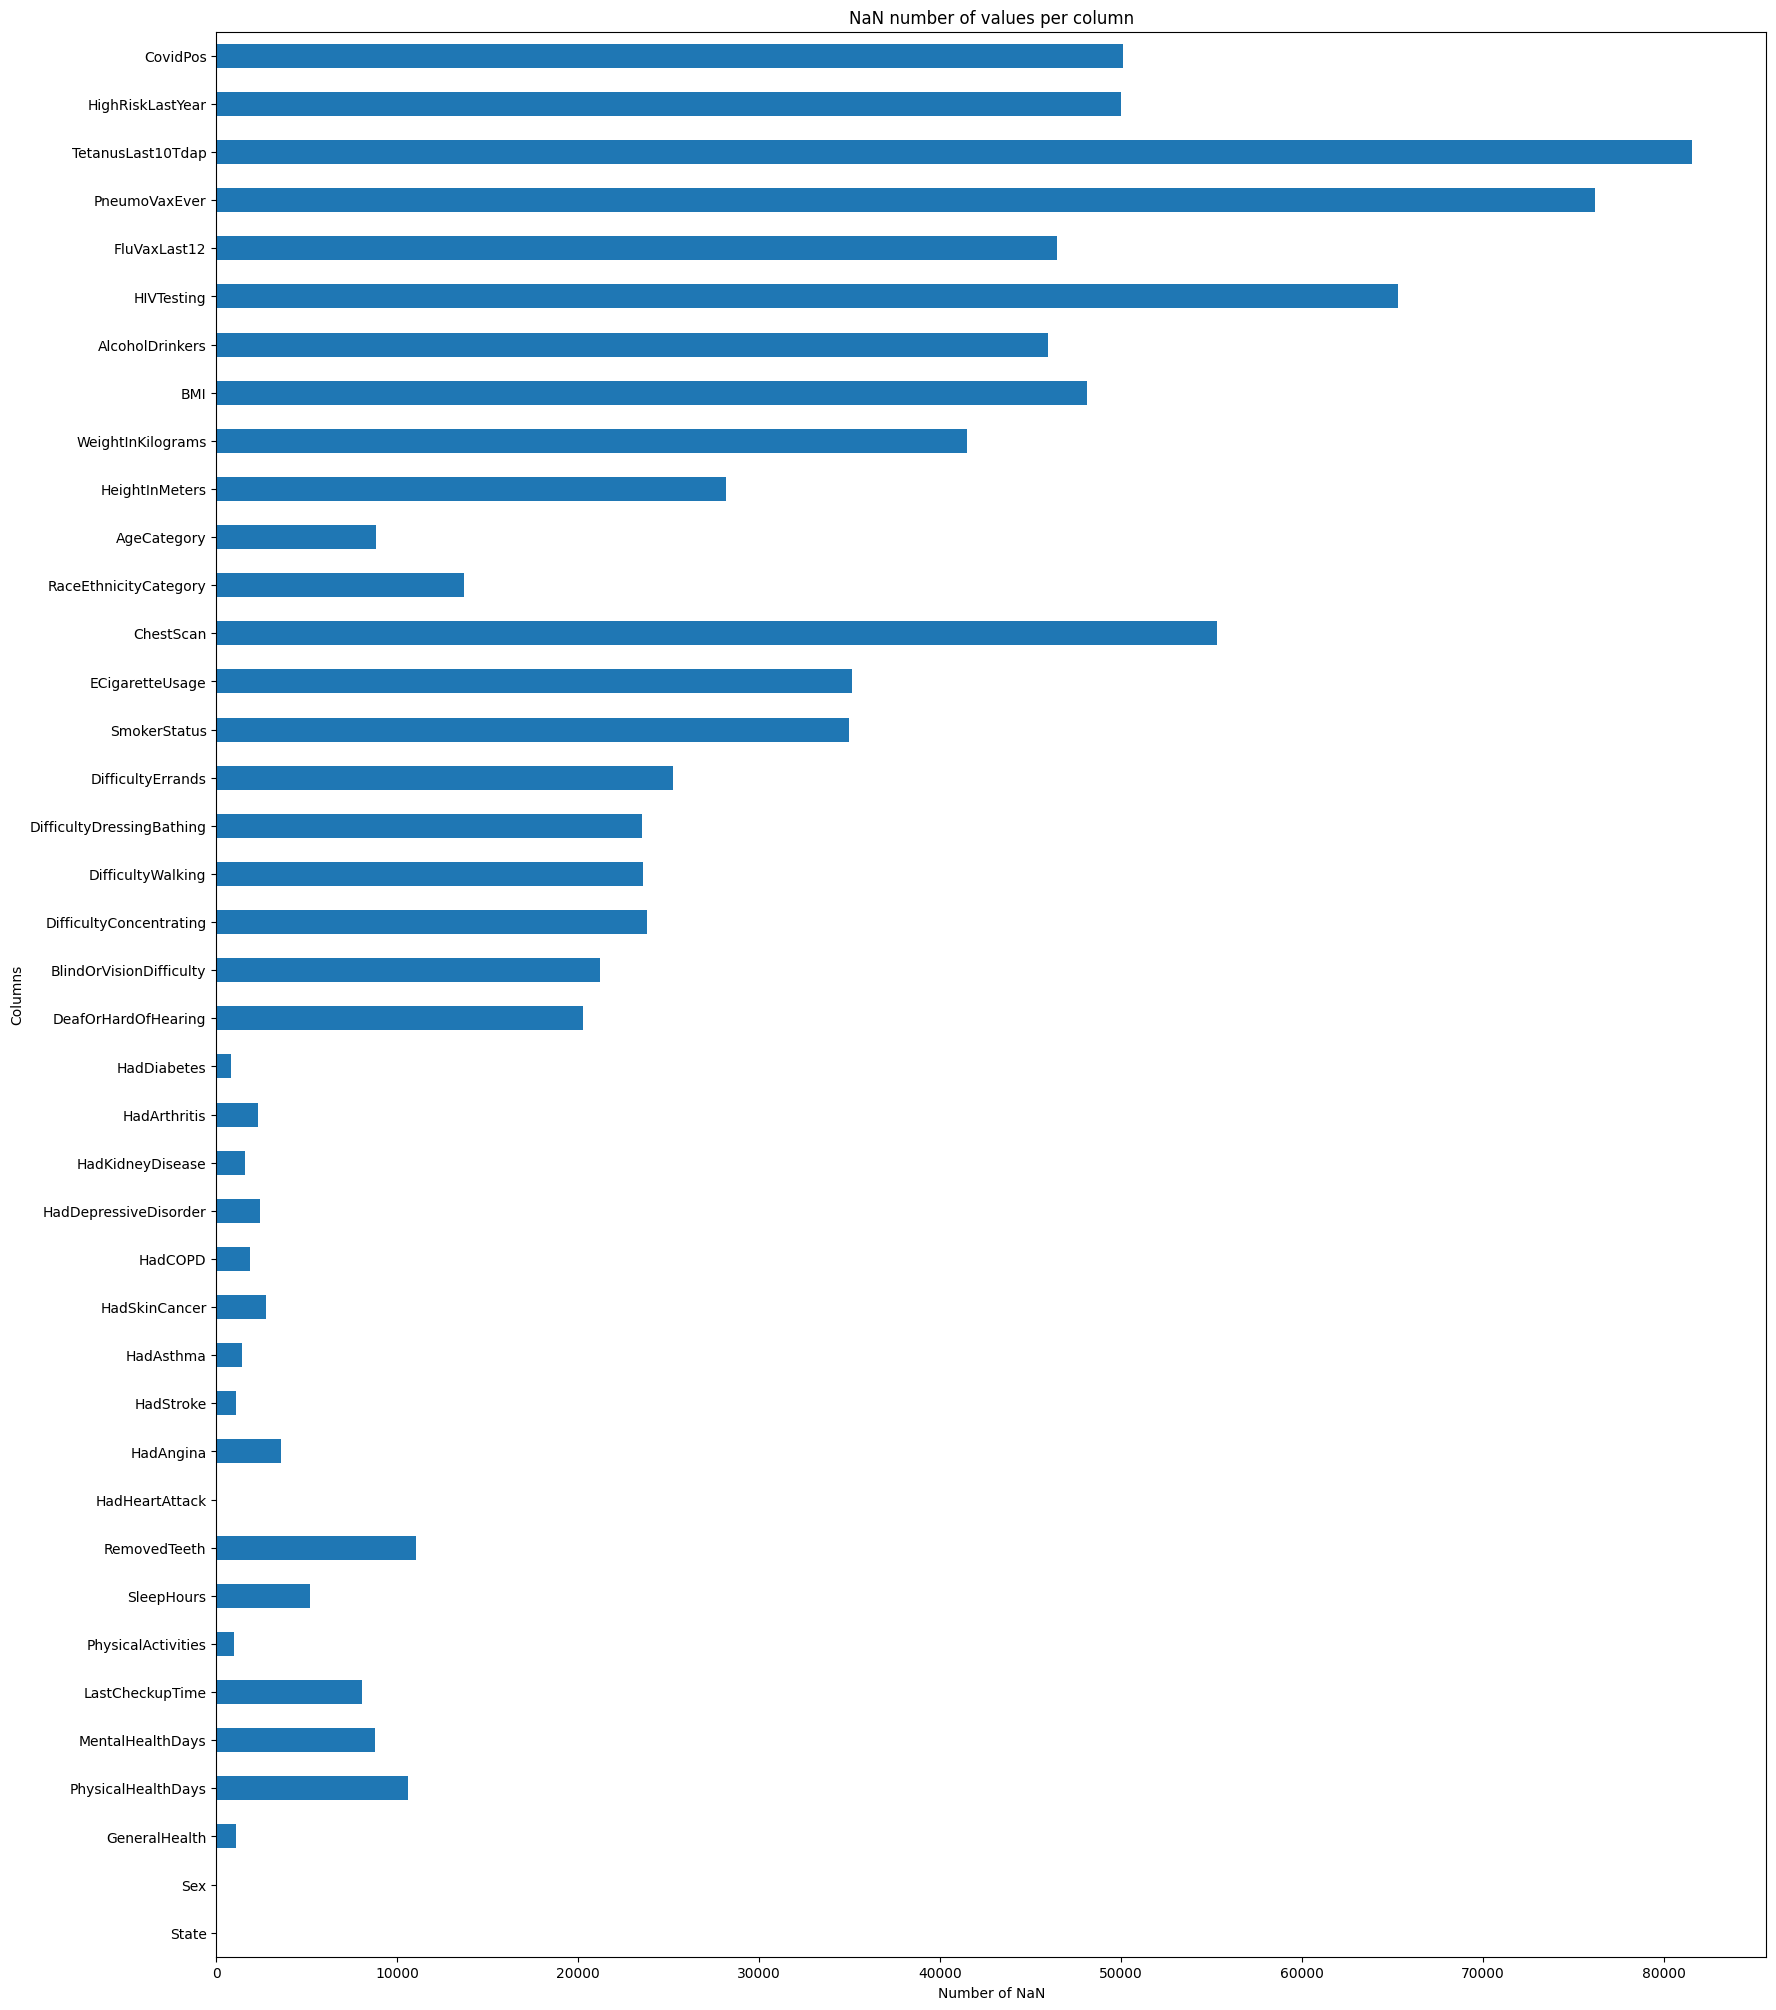

State                            0
Sex                              0
GeneralHealth                 1095
PhysicalHealthDays           10597
MentalHealthDays              8792
LastCheckupTime               8041
PhysicalActivities             972
SleepHours                    5196
RemovedTeeth                 11010
HadHeartAttack                   0
HadAngina                     3588
HadStroke                     1070
HadAsthma                     1437
HadSkinCancer                 2764
HadCOPD                       1838
HadDepressiveDisorder         2421
HadKidneyDisease              1614
HadArthritis                  2313
HadDiabetes                    813
DeafOrHardOfHearing          20278
BlindOrVisionDifficulty      21190
DifficultyConcentrating      23795
DifficultyWalking            23604
DifficultyDressingBathing    23513
DifficultyErrands            25231
SmokerStatus                 34941
ECigaretteUsage              35143
ChestScan                    55288
RaceEthnicityCategor

In [ ]:

# Построим диаграмму, что проверить есть NaN значения в датасете
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 25))


nan_counts = df.isna().sum()

nan_counts.plot(kind='barh')
plt.title('NaN number of values ​​per column')
plt.ylabel('Columns')
plt.xlabel('Number of NaN')


plt.xticks(rotation=0)
plt.show()


print(nan_counts)


#Having analyzed the diagrams, we can see that there are quite a lot of NaN values ​​in the columns, and if we strangle them all, we will lose part of the dataset. In the next steps I will describe how I will deal with this situation.

In [ ]:
df.shape

(442067, 40)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
y_train.value_counts(normalize=True)

HadHeartAttack
No     0.943204
Yes    0.056796
Name: proportion, dtype: float64

#Now we can see that our classes are unbalanced but I will deal with the unbalanced class after analyzing and transforming the dataset.


In [ ]:
df_train=pd.concat([X_train,y_train],axis=1)
df_train.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
349425,Texas,Female,Fair,15.0,30.0,Within past year (anytime less than 12 months ...,Yes,4.0,"6 or more, but not all",No,...,48.53,17.27,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No
149324,Maine,Male,Very good,0.0,3.0,Within past year (anytime less than 12 months ...,No,7.0,None of them,No,...,113.40,32.98,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,No
64211,Florida,Female,Poor,30.0,0.0,NaN,No,7.0,None of them,No,...,58.51,21.47,NaN,Yes,Yes,No,"Yes, received tetanus shot, but not Tdap",No,No,No
43949,Colorado,Male,Excellent,0.0,0.0,NaN,Yes,8.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
287847,Ohio,Female,Very good,5.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,No,...,49.90,20.12,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No


#EDA
see at data and try to understarnd its meaning

correlation, ets

missed values -- lets remove all raws with more then N(N in our case N=5, because the percentage of people with N=5+ is only 10%) empty values | remove empty rows | remove empty columns

not balansed! -- need to handle: upsampling, downsampling, class_weights

encoding:

external sources

target encoding

remove uselss feature (?)

'Poor' (0) < 'Very good' (10) label encoding

fit(train) -> transform(test)    

In [ ]:
df_train['empty_counts']=df.isnull().sum(axis=1)


In [ ]:
df_train['empty_counts'].value_counts()

empty_counts
0     196660
1      69645
2      29221
3      12510
19     10430
4       5506
10      4949
8       3465
5       2956
6       2735
7       2264
20      2186
11      1736
9       1719
12      1330
13      1264
16      1117
14      1063
15      1009
18       669
21       623
17       337
22       159
23        62
24        18
25         7
26         5
27         4
29         3
28         1
Name: count, dtype: int64

In [ ]:
df_train=df_train[df_train['empty_counts']<5]

In [ ]:
df_train['empty_counts'].value_counts()

empty_counts
0    196660
1     69645
2     29221
3     12510
4      5506
Name: count, dtype: int64

#Now we need to analyze our data: which of them are categorical and which are numeric

In [ ]:

numeric_features = df.select_dtypes(include=['int', 'float']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical signs:", numeric_features)
print("Categorical features:", categorical_features)

Numerical signs: Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')
Categorical features: Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')


In [ ]:
for column in categorical_features:
      unique_count = df[column].nunique()
      print(f"Column '{column}' has {unique_count} unique values: {df[column].unique()}")


Column 'State' has 54 unique values: ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']
Column 'Sex' has 2 unique values: ['Female' 'Male']
Column 'GeneralHealth' has 5 unique values: ['Very good' 'Excellent' 'Fair' 'Poor' 'Good' nan]
Column 'LastCheckupTime' has 4 unique values: ['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within p

##It can be seen that there is a lot of categorical data in this dataset.

##I will consider each feature and convert it to numeric values.

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])

In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,0,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,0,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,0,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,0,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,0,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445127,Virgin Islands,0,Good,0.0,3.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,...,1.65,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
445128,Virgin Islands,0,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
445129,Virgin Islands,0,Poor,30.0,30.0,5 or more years ago,No,5.0,1 to 5,No,...,1.70,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
445130,Virgin Islands,1,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,...,1.83,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes


54


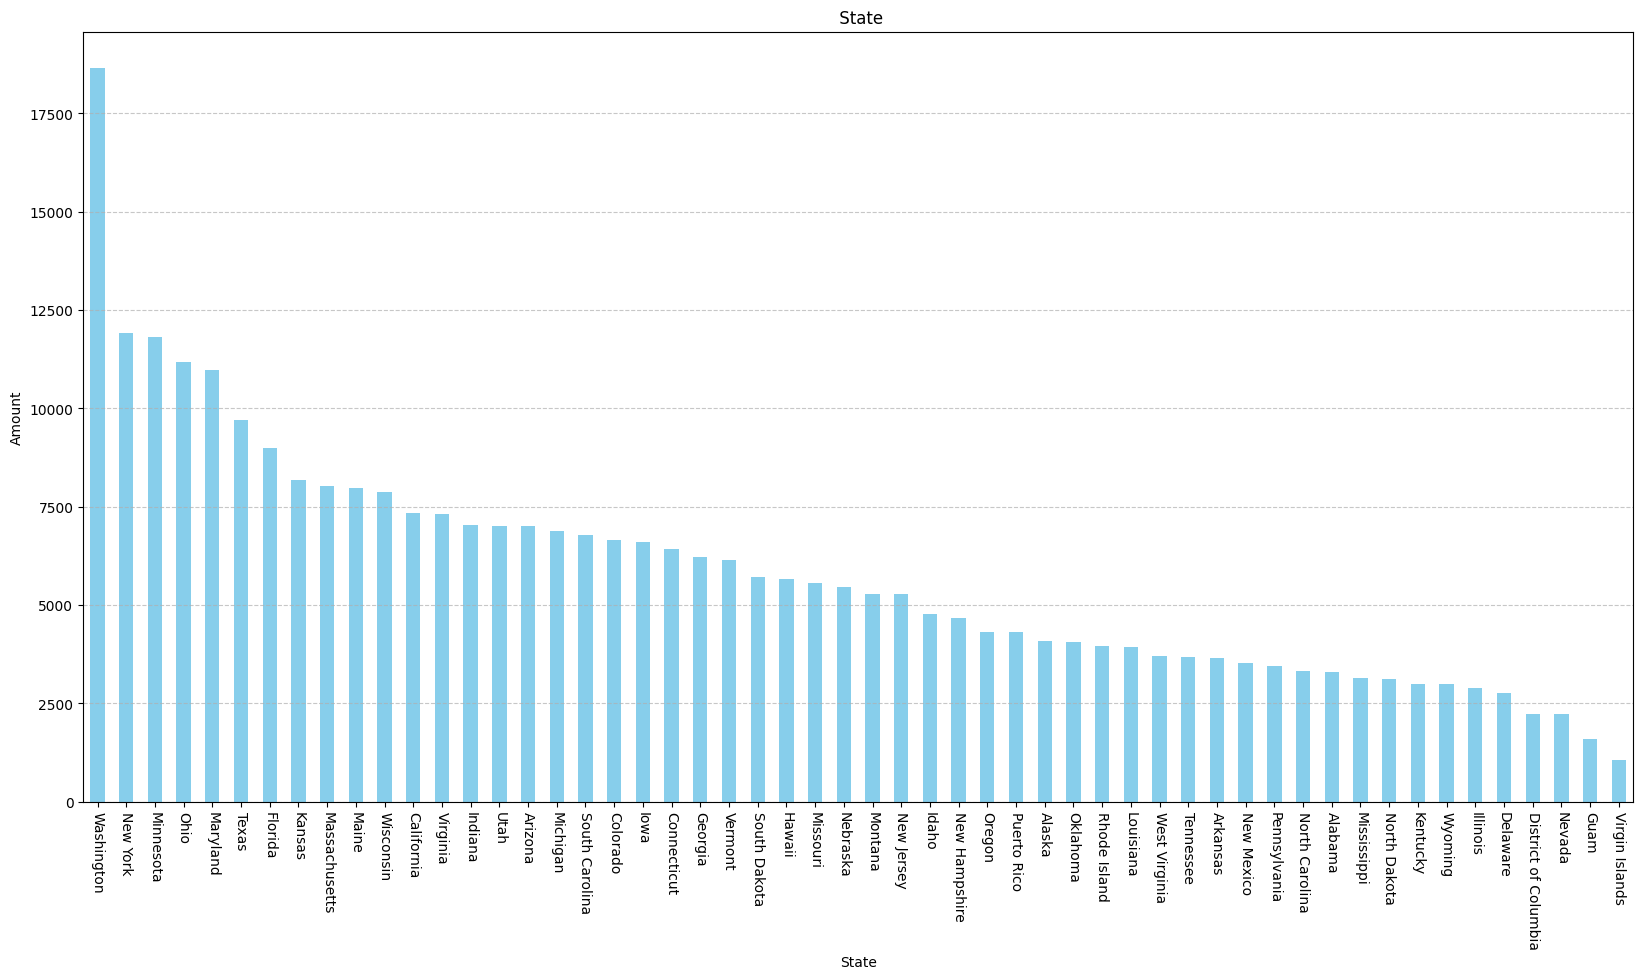

In [ ]:
state_counts = df_train['State'].value_counts()
print(len(df_train['State'].unique()))
# Построение столбчатой диаграммы
plt.figure(figsize=(20, 10))
state_counts.plot(kind='bar', color='skyblue')
plt.title(' State')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##It can be seen that there are different numbers of people in State, so it would be irrational to estimate only the number of our target value in State. To do this, the following transformations will be made:

In [ ]:
df['HadHeartAttack_BIN'] = df['HadHeartAttack'].map({'Yes': 1, 'No': 0})

In [ ]:
agg_data_ha = df.groupby('State').agg(
    ha_count=('HadHeartAttack_BIN', 'count'),  # количество записей по каждому штату
    ha_pos=('HadHeartAttack_BIN', 'sum')  # сумма значений 'HadHeartAttack_BIN' (количество случаев с инфарктом)
).reset_index()

In [ ]:
agg_data_ha['ratio']=agg_data_ha['ha_pos']/agg_data_ha['ha_count']
agg_data_ha.sort_values(by='ratio',ascending=False)
agg_data_ha['ratio_norm']=agg_data_ha['ratio']/agg_data_ha['ratio'].sum()*100
agg_data_ha.sort_values(by='ratio',ascending=False)

,State,ha_count,ha_pos,ratio,ratio_norm
51,West Virginia,4945,444,0.089788,2.891001
3,Arkansas,5241,454,0.086625,2.789159
9,Florida,13282,1018,0.076645,2.467833
30,New Hampshire,6706,500,0.074560,2.400701
37,Oklahoma,5707,412,0.072192,2.324454
18,Kentucky,4004,289,0.072178,2.323996
44,Tennessee,5234,371,0.070883,2.282295
20,Maine,10584,750,0.070862,2.281618
2,Arizona,10089,708,0.070175,2.259523
0,Alabama,4475,312,0.069721,2.244880


In [ ]:
df= pd.merge(df, agg_data_ha[['State', 'ratio_norm']], on='State', how='left')

In [ ]:
df['State']=df['ratio_norm']
df = df.drop('ratio_norm', axis=1)

In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,Good,0.0,3.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,Poor,30.0,30.0,5 or more years ago,No,5.0,1 to 5,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


## Now about GeneralHealth

6


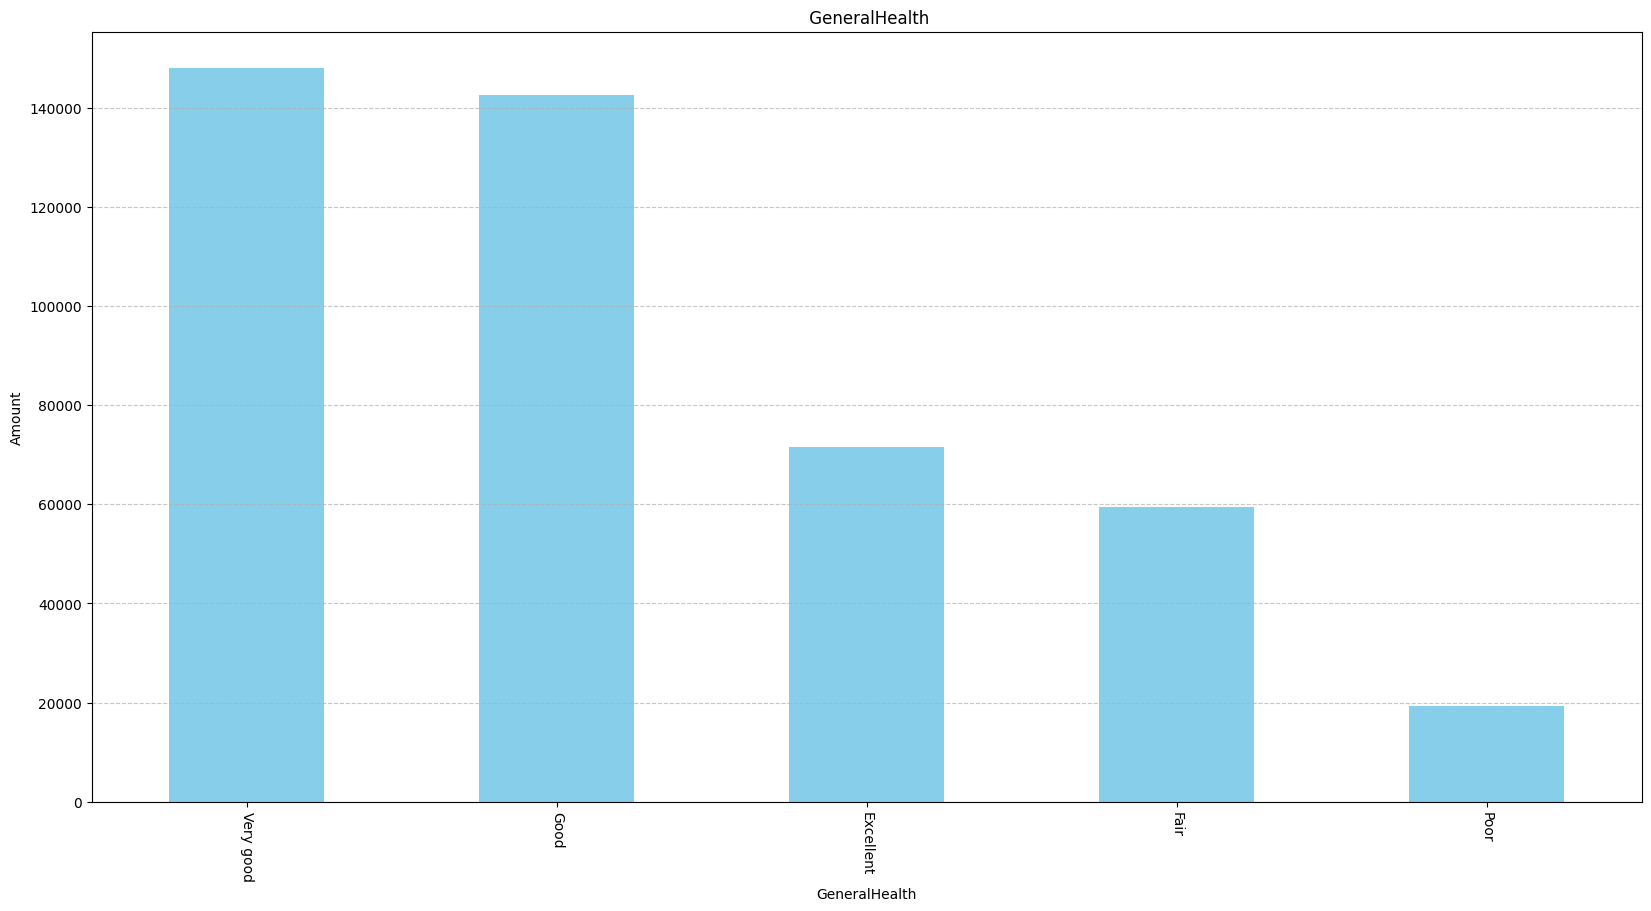

In [ ]:


GeneralHealth = df['GeneralHealth'].value_counts()
print(len(df['GeneralHealth'].unique()))

plt.figure(figsize=(20, 10))
GeneralHealth.plot(kind='bar', color='skyblue')
plt.title(' GeneralHealth')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
an_count = df['GeneralHealth'].isna().sum()
print(an_count)


1095


##I will fill Nan values ​​with the average value - Good

In [ ]:
df['GeneralHealth'] = df['GeneralHealth'].fillna('Good')

In [ ]:
an_count = df['GeneralHealth'].isna().sum()
print(an_count)


0


In [ ]:
priorities = {'Very good': 4, 'Good': 3, 'Excellent': 5,'Fair':2,'Poor':1}
label_encoder = LabelEncoder()
df['GeneralHealth'] = df['GeneralHealth'].map(lambda x: priorities[x])

##And now about LastCheckupTime

5


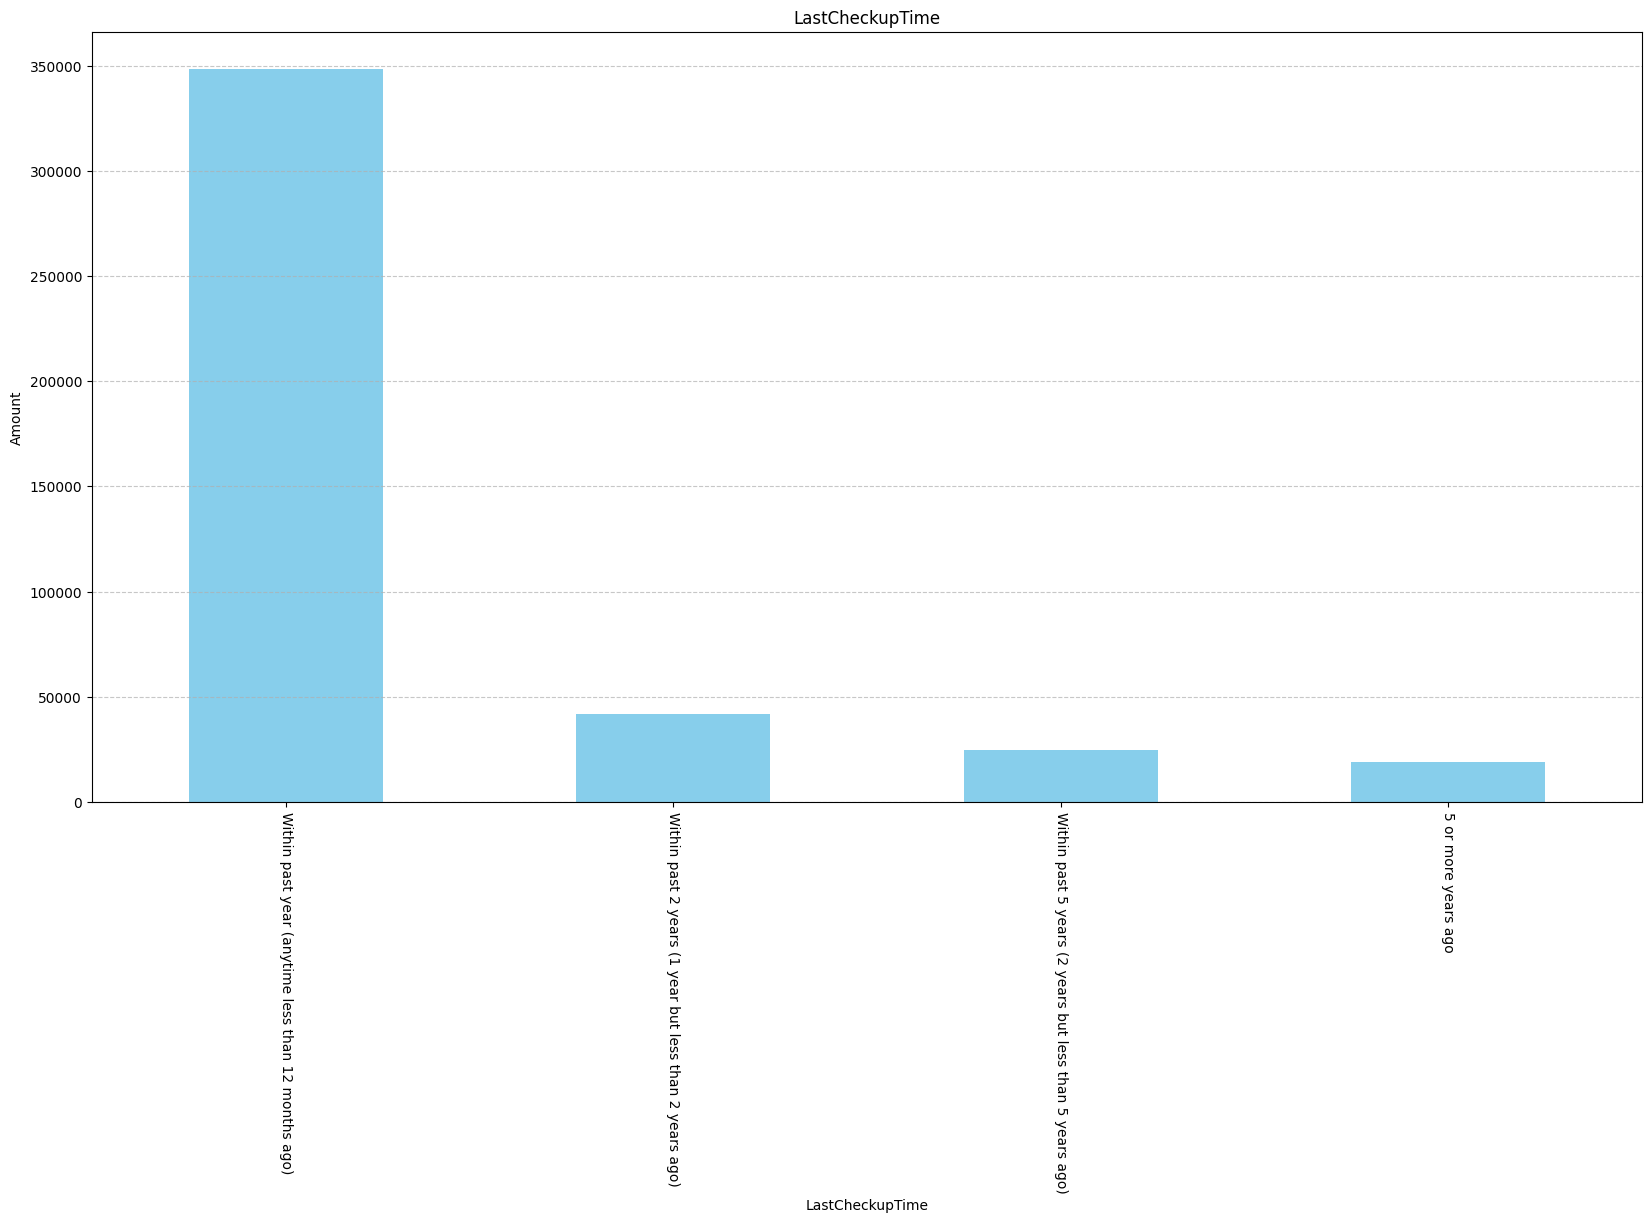

In [ ]:

LastCheckupTime = df['LastCheckupTime'].value_counts()
print(len(df['LastCheckupTime'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('LastCheckupTime')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# Изучив график можно сделать вывод, что 4 времени  можно разделить на 3 группы приоритета.
# поэтому для LastCheckupTime буду использовать LabelEncoder. В дальнейшем подразумеваются похожего рода рассуждения, которые обоснованы показателями графиков

df['LastCheckupTime'] = df['LastCheckupTime'].fillna('Within past 2 years (1 year but less than 2 years ago)')


priorities = {'Within past year (anytime less than 12 months ago)': 3, 'Within past 2 years (1 year but less than 2 years ago)': 2, 'Within past 5 years (2 years but less than 5 years ago)': 1,'5 or more years ago':1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
'''
['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within past 5 years (2 years but less than 5 years ago)'
 '5 or more years ago']
 '''


df['LastCheckupTime'] = df['LastCheckupTime'].map(lambda x: priorities[x])

##And now about PhysicalActivities

3


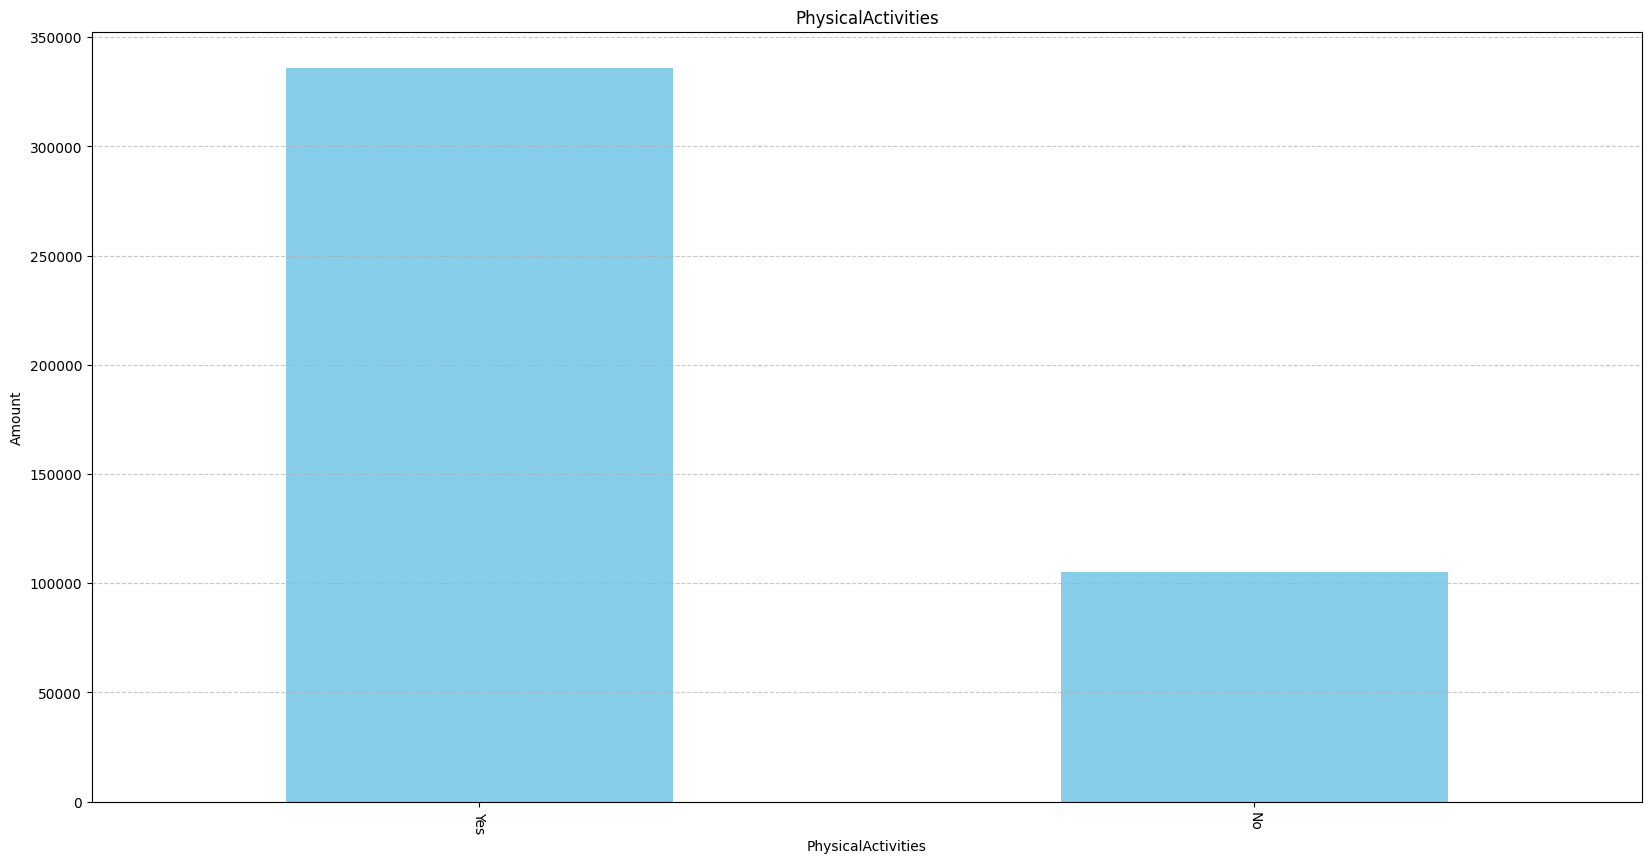

In [ ]:

LastCheckupTime = df['PhysicalActivities'].value_counts()
print(len(df['PhysicalActivities'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('PhysicalActivities')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
Nan_count = df['PhysicalActivities'].isna().sum()
print(Nan_count)

df['PhysicalActivities'] = label_encoder.fit_transform(df['PhysicalActivities'])

972


In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,NaN,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,NaN,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,NaN,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,NaN,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,NaN,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,None of them,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,None of them,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,1 to 5,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,None of them,Yes,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


##And now about RemovedTeeth

5


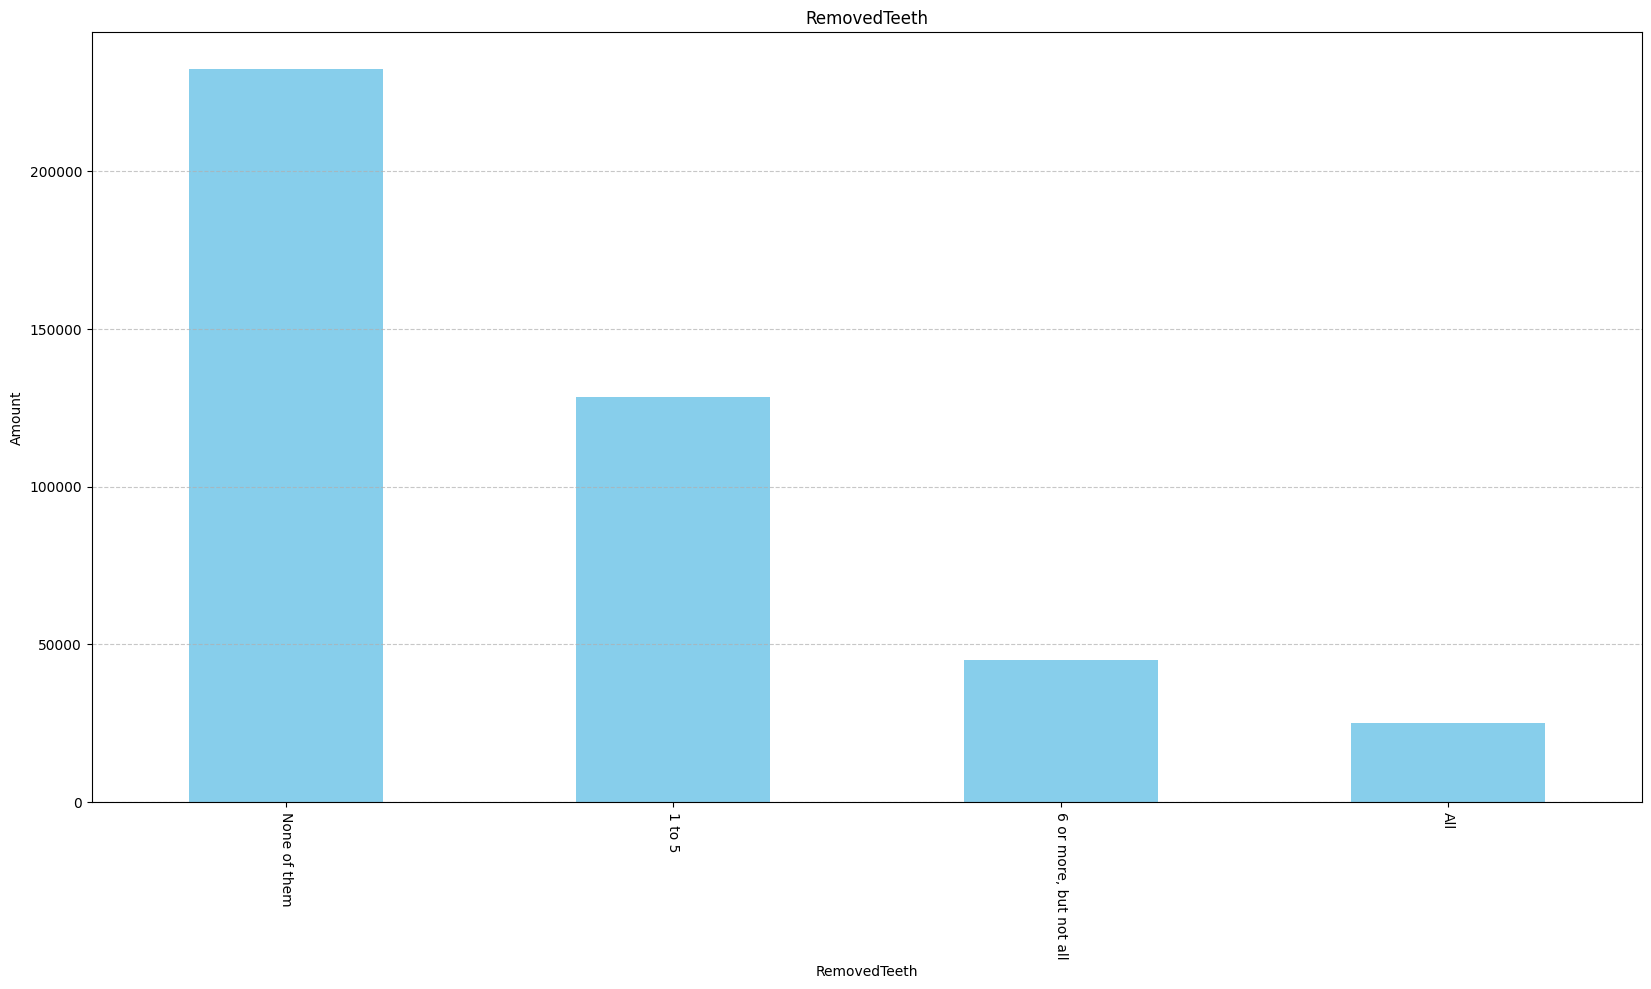

In [ ]:

LastCheckupTime = df['RemovedTeeth'].value_counts()
print(len(df['RemovedTeeth'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('RemovedTeeth')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:

priorities = {'None of them': 3, '1 to 5': 2, '6 or more, but not all': 1,'All':0}
label_encoder = LabelEncoder()
df['RemovedTeeth'] = df['RemovedTeeth'].fillna('1 to 5')

df['RemovedTeeth'] = df['RemovedTeeth'].map(lambda x: priorities[x])

In [ ]:
df.drop('HadHeartAttack', axis=1, inplace=True)

In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,No,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


##And now about HadAngina

In [ ]:
df['HadAngina'] = label_encoder.fit_transform(df['HadAngina'])

In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,0,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,0,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,0,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,0,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,0,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,0,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,0,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,0,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,0,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


In [ ]:
df['HadAngina'] = label_encoder.fit_transform(df['HadAngina'])

In [ ]:
# Список столбцов, которые нужно закодировать
columns_to_encode = ['HadStroke', 'HadAsthma', 'HadSkinCancer','HadCOPD','HadDepressiveDisorder','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','BlindOrVisionDifficulty','DifficultyConcentrating','DifficultyWalking','DifficultyDressingBathing','DifficultyErrands','ChestScan','AlcoholDrinkers','HIVTesting','FluVaxLast12','PneumoVaxEver','HighRiskLastYear']


label_encoder = LabelEncoder()
df[columns_to_encode] = df[columns_to_encode].apply(lambda col: label_encoder.fit_transform(col))


##And now about HadDiabetes

5


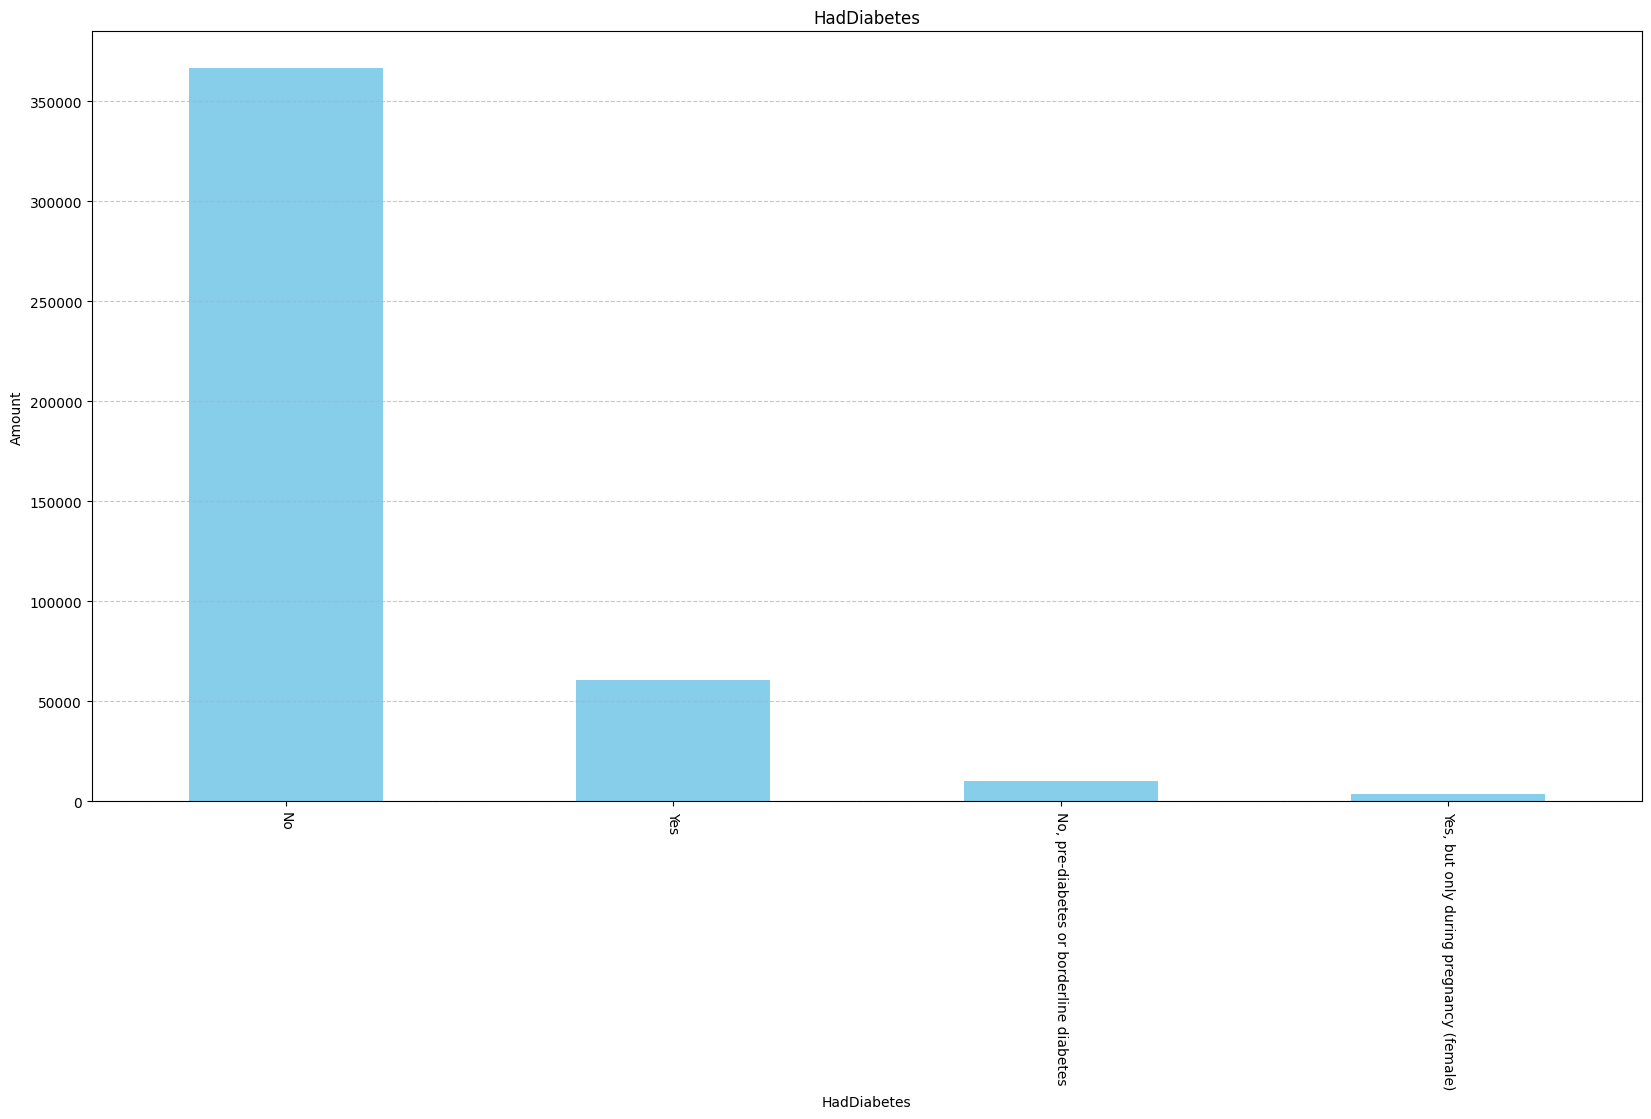

In [ ]:

LastCheckupTime = df['HadDiabetes'].value_counts()
print(len(df['HadDiabetes'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('HadDiabetes')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:

priorities = {'Yes': 1, 'No': 0, 'No, pre-diabetes or borderline diabetes': 0.5,'Yes, but only during pregnancy (female)':0}
label_encoder = LabelEncoder()
df['HadDiabetes'] = df['HadDiabetes'].fillna('No')

df['HadDiabetes'] = df['HadDiabetes'].map(lambda x: priorities[x])

5


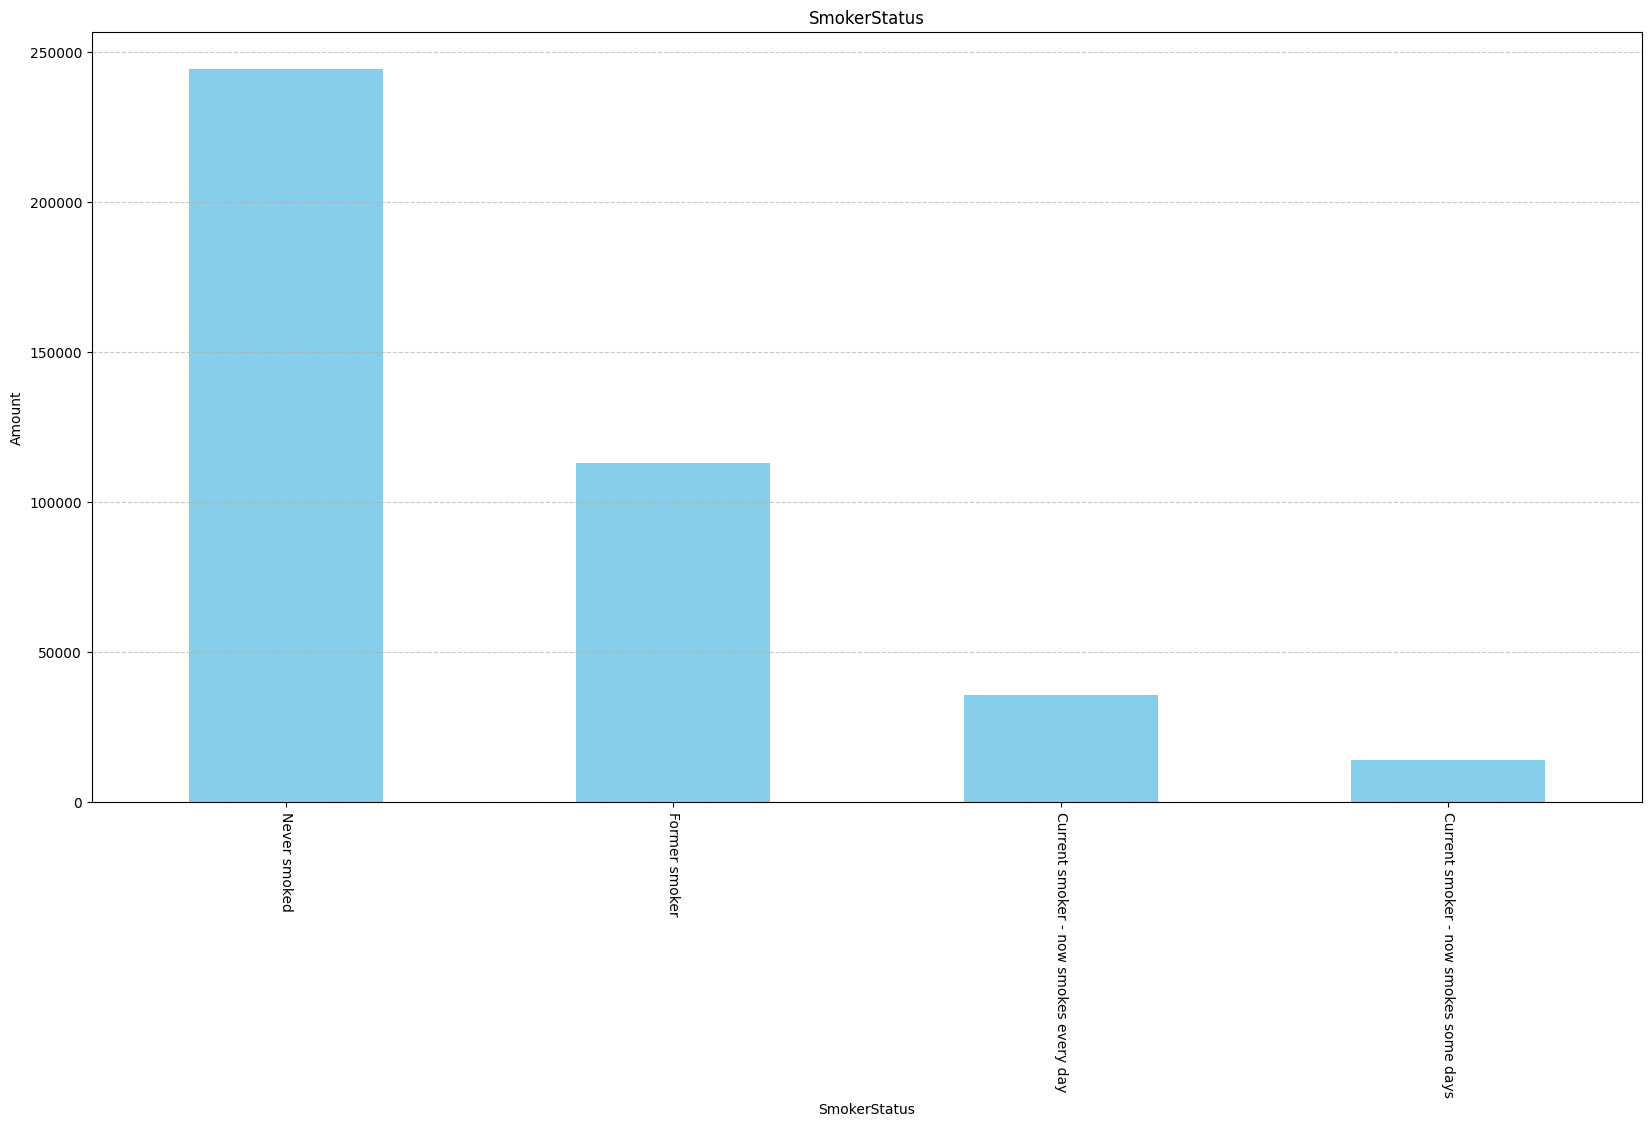

In [ ]:

LastCheckupTime = df['SmokerStatus'].value_counts()
print(len(df['SmokerStatus'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('SmokerStatus')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['SmokerStatus'] = df['SmokerStatus'].fillna('Never smoked')


priorities = {'Never smoked': 3, 'Former smoker': 2, 'Current smoker - now smokes some days': 1,'Current smoker - now smokes every day':0.5}


label_encoder = LabelEncoder()


df['SmokerStatus'] = df['SmokerStatus'].map(lambda x: priorities[x])


In [ ]:
df['SmokerStatus']

0         3.0
1         3.0
2         3.0
3         1.0
4         3.0
         ... 
442062    3.0
442063    3.0
442064    0.5
442065    3.0
442066    2.0
Name: SmokerStatus, Length: 442067, dtype: float64

5


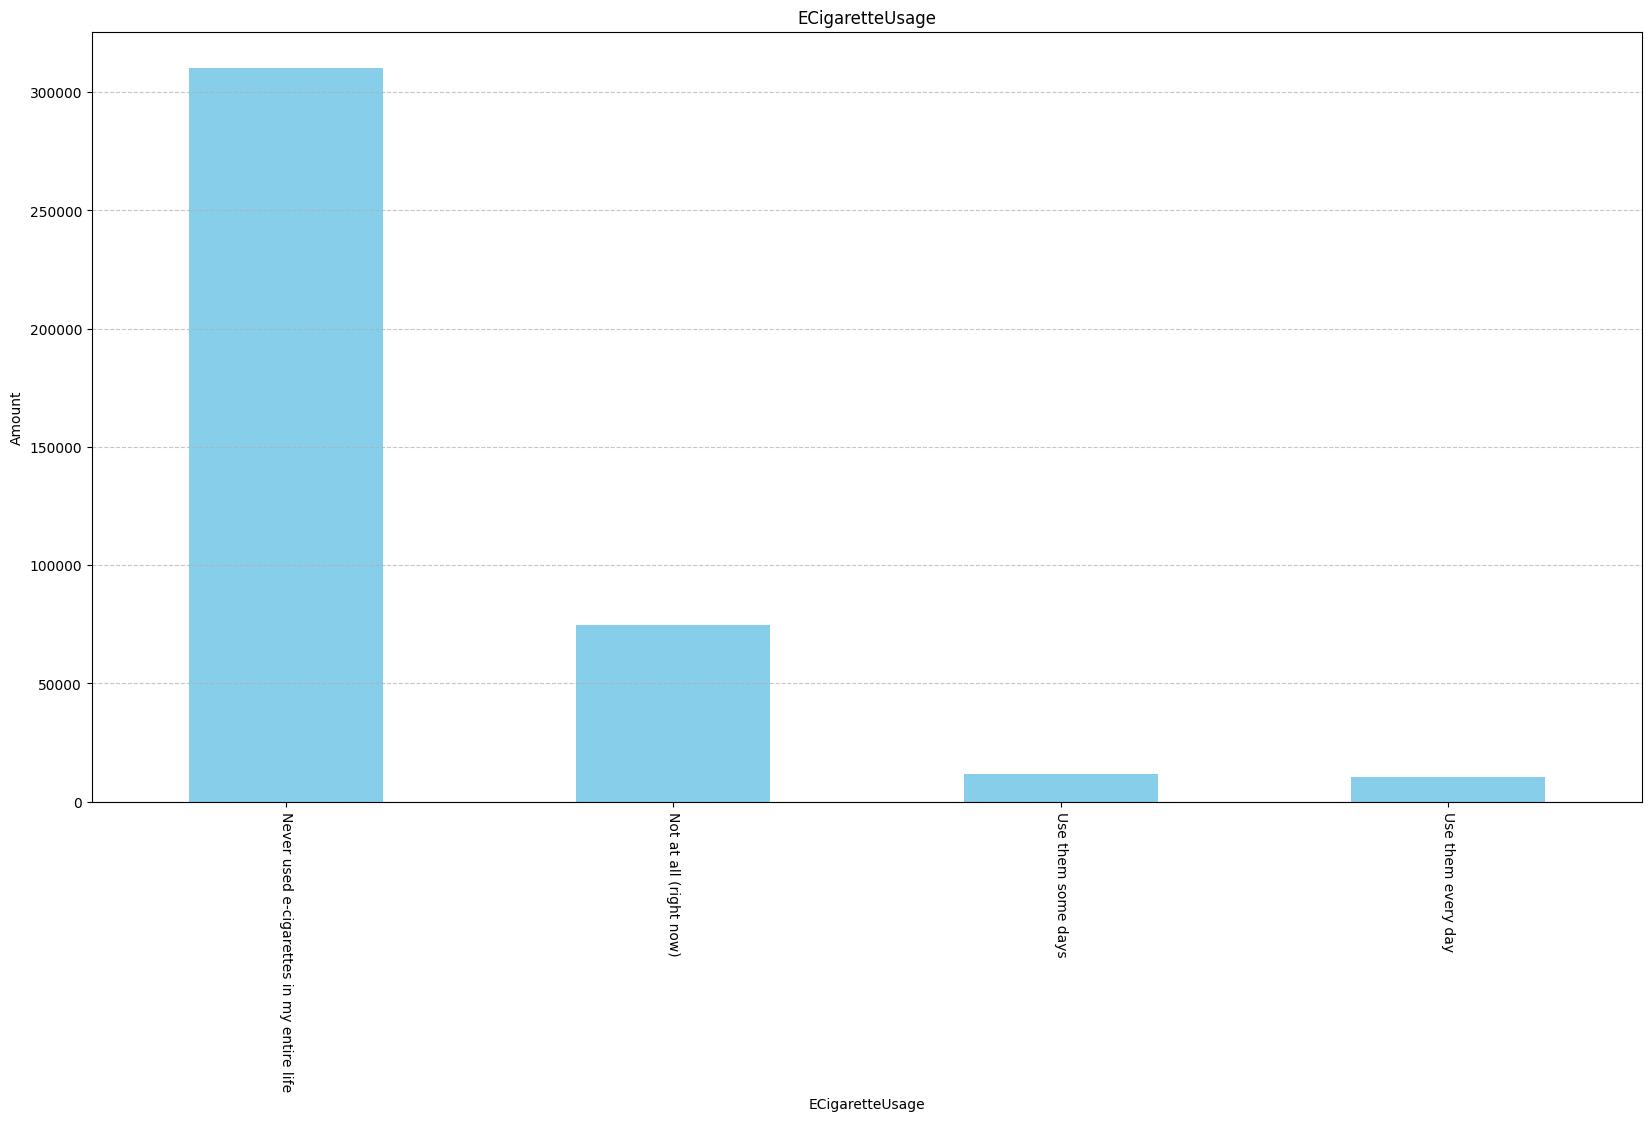

In [ ]:

LastCheckupTime = df['ECigaretteUsage'].value_counts()
print(len(df['ECigaretteUsage'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('ECigaretteUsage')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['ECigaretteUsage'] = df['ECigaretteUsage'].fillna('Never used e-cigarettes in my entire life')


priorities = {'Never used e-cigarettes in my entire life': 3, 'Not at all (right now)': 2, 'Use them every day': 1,'Use them some days':1}


label_encoder = LabelEncoder()


df['ECigaretteUsage'] = df['ECigaretteUsage'].map(lambda x: priorities[x])


6


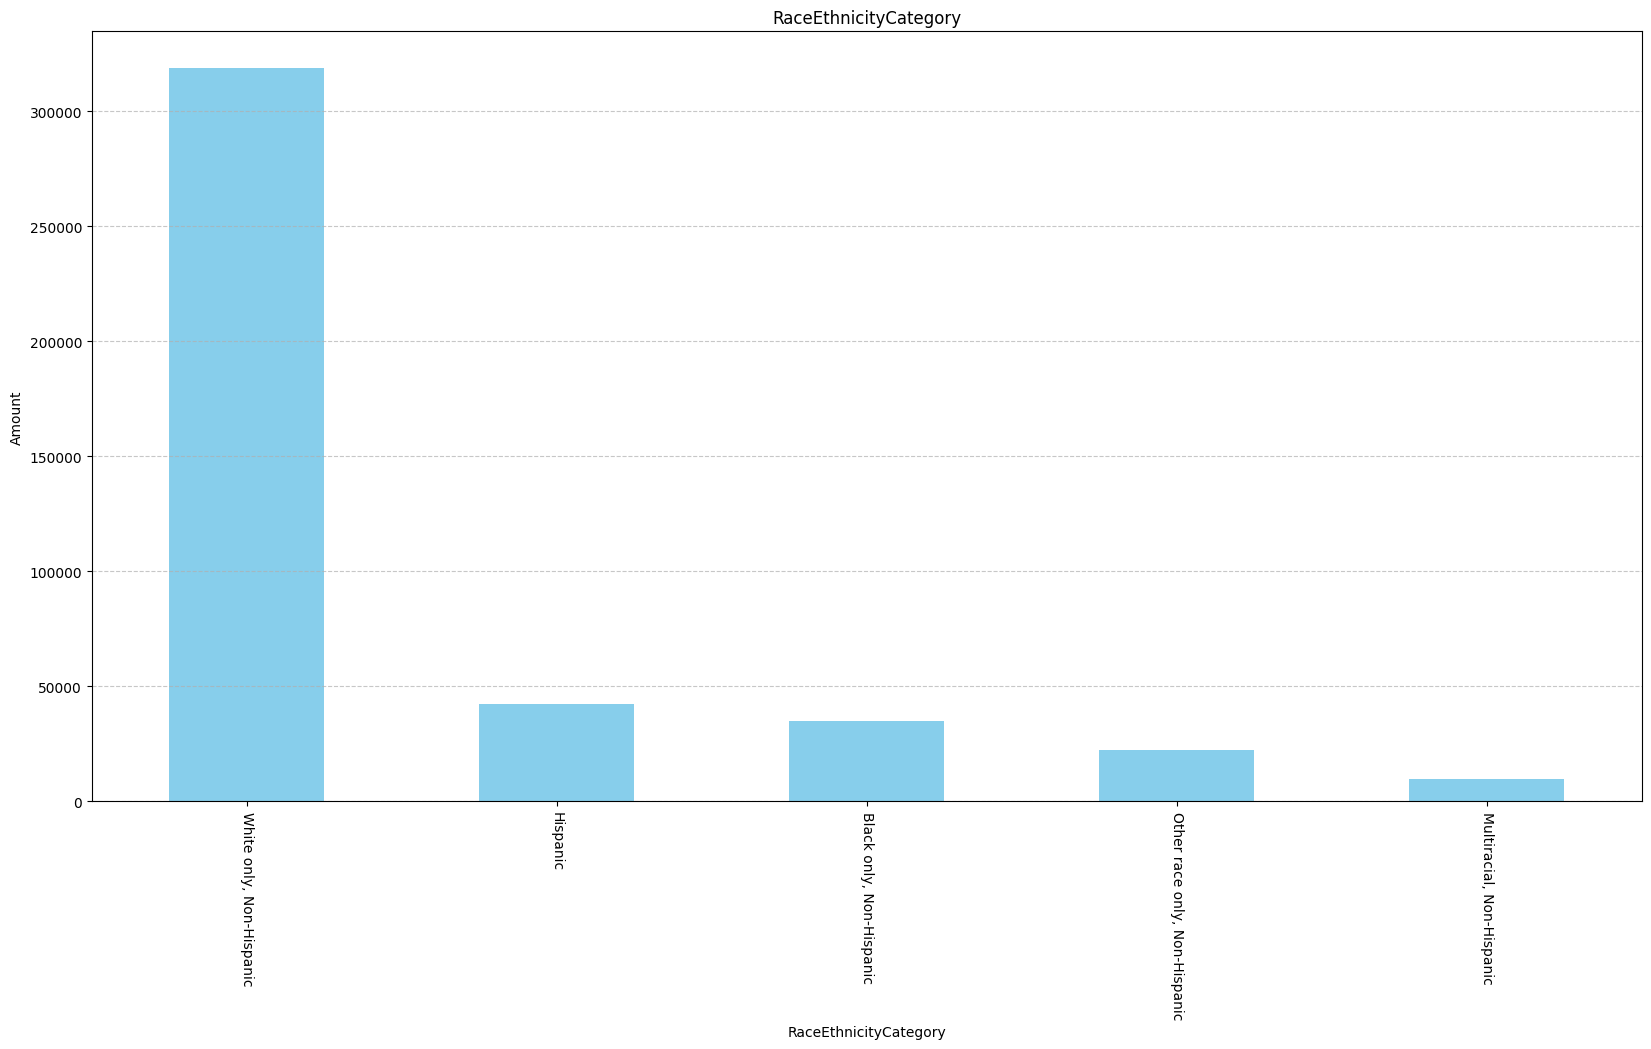

In [ ]:

LastCheckupTime = df['RaceEthnicityCategory'].value_counts()
print(len(df['RaceEthnicityCategory'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('RaceEthnicityCategory')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['RaceEthnicityCategory'] = df['RaceEthnicityCategory'].fillna('White only, Non-Hispanic')

df['RaceEthnicityCategory'] = label_encoder.fit_transform(df['RaceEthnicityCategory'])


14


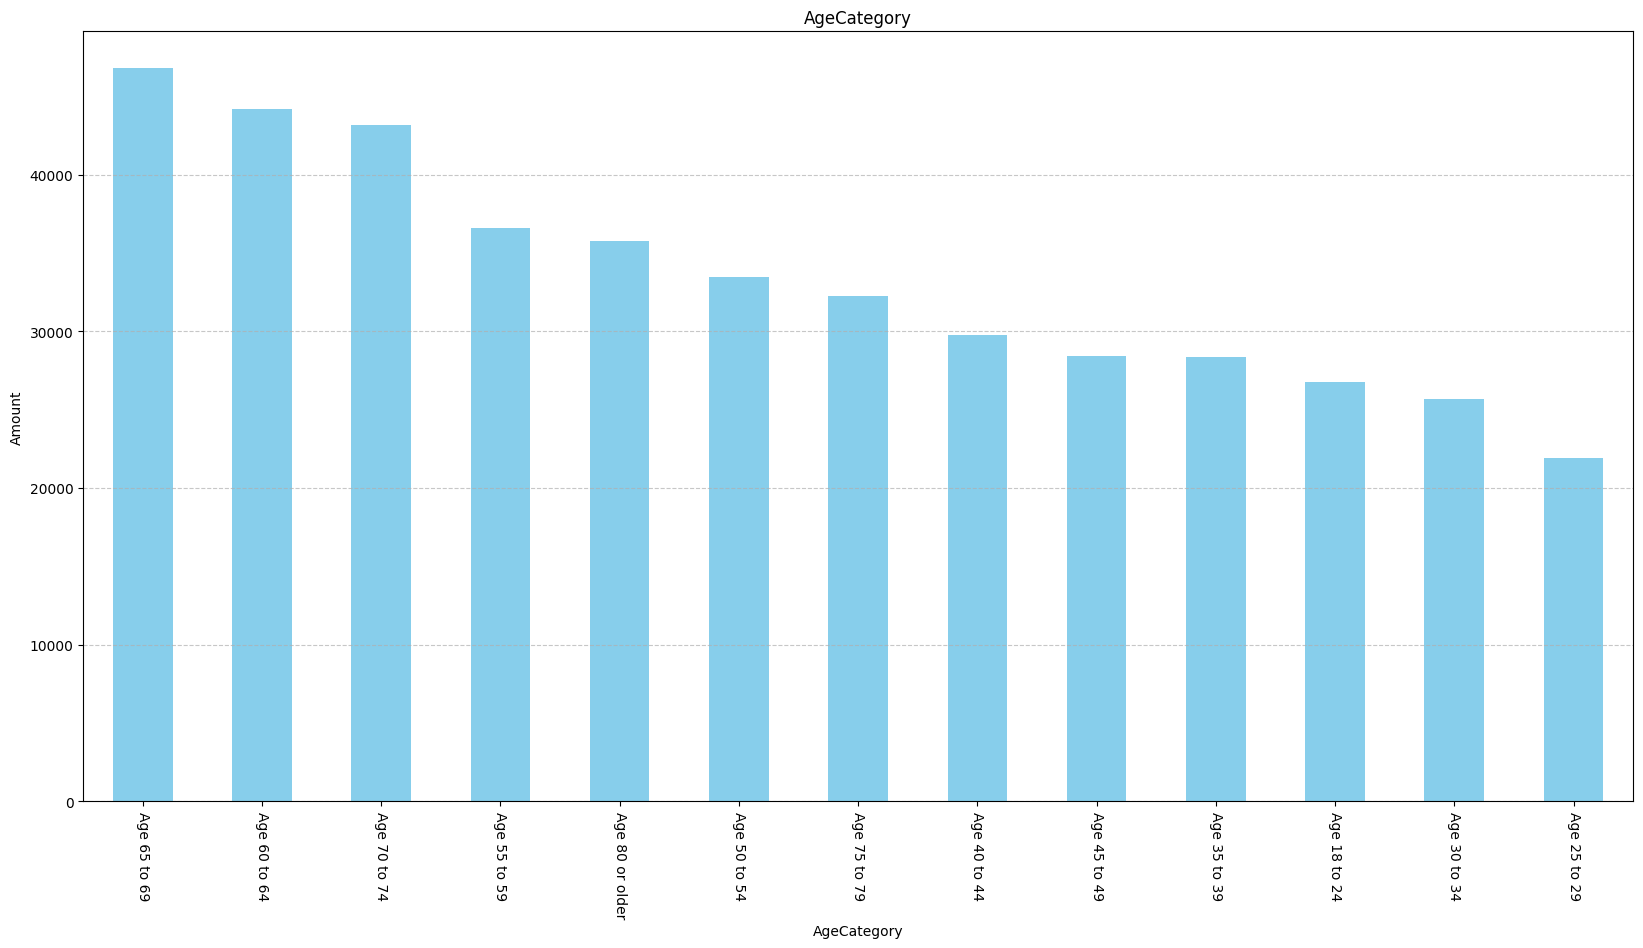

In [ ]:

LastCheckupTime = df['AgeCategory'].value_counts()
print(len(df['AgeCategory'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('AgeCategory')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['AgeCategory'] = label_encoder.fit_transform(df['AgeCategory'])

5


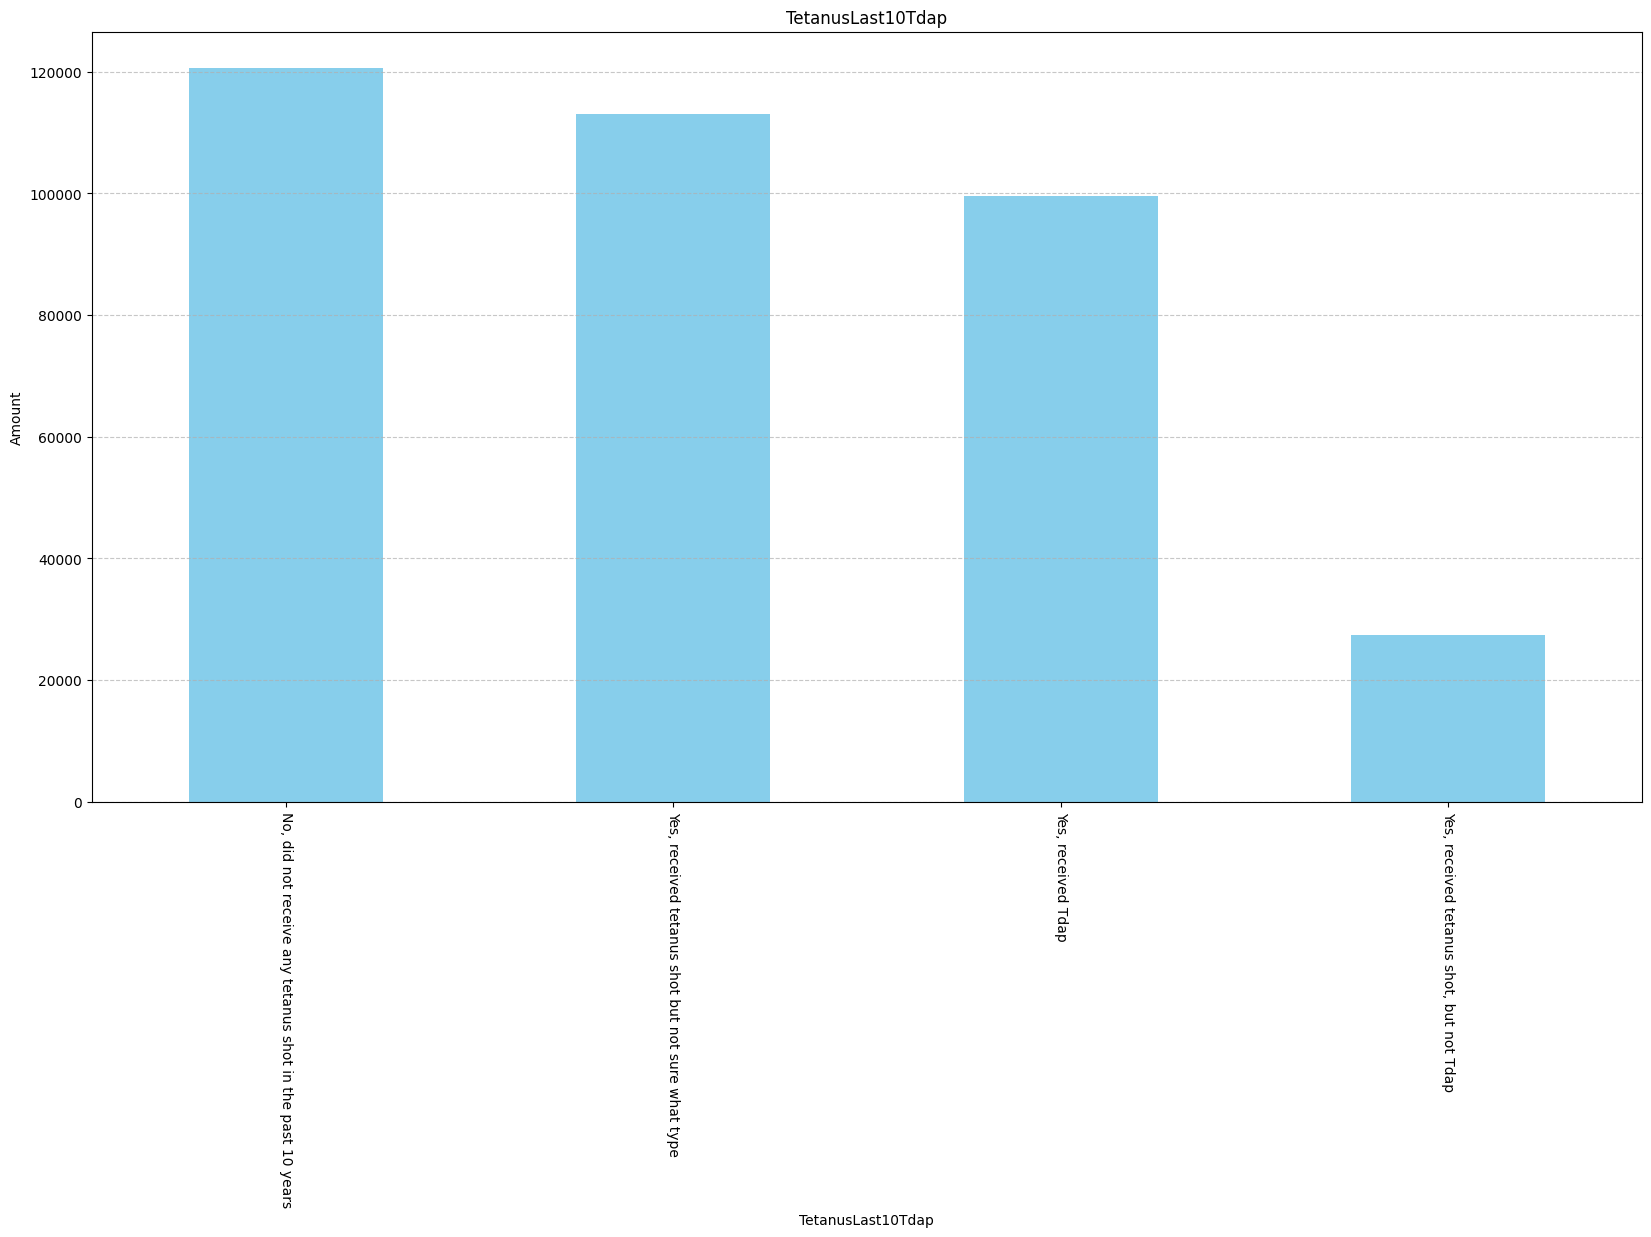

In [ ]:

LastCheckupTime = df['TetanusLast10Tdap'].value_counts()
print(len(df['TetanusLast10Tdap'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('TetanusLast10Tdap')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['TetanusLast10Tdap'] = df['TetanusLast10Tdap'].fillna('No, did not receive any tetanus shot in the past 10 years')


priorities = {'No, did not receive any tetanus shot in the past 10 years': 4, 'Yes, received tetanus shot but not sure what type': 3,
              'Yes, received Tdap': 2,'Yes, received tetanus shot, but not Tdap':1}


label_encoder = LabelEncoder()


df['TetanusLast10Tdap'] = df['TetanusLast10Tdap'].map(lambda x: priorities[x])


In [ ]:
df['CovidPos'] = label_encoder.fit_transform(df['CovidPos'])

In [ ]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,0,...,NaN,NaN,0,0,1,0,3,0,0,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,0,...,68.04,26.57,0,0,0,0,4,0,0,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,0,...,63.50,25.61,0,0,0,0,4,0,2,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,0,...,63.50,23.30,0,0,1,1,4,0,0,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,0,...,53.98,21.77,1,0,0,1,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,0,...,69.85,25.63,2,1,0,0,4,0,2,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,0,...,83.01,28.66,0,1,1,0,3,0,0,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,0,...,49.90,17.23,2,0,0,0,4,0,0,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,0,...,108.86,32.55,0,1,1,1,4,0,2,1


In [ ]:

numeric_features = df.select_dtypes(include=['int', 'float']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical signs:", numeric_features)
print("Categorical features:", categorical_features)

Numerical signs: Index(['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays',
       'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities',
       'SleepHours', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos',
       'HadHeartAttack_BIN'],
      dtype='object')
Categorical features: Index([], dtype='object')


#HOORAY! Now we have ONLY numerical data and we can build thermal correlation matrices to analyze the influence coefficients of parameters. Each parameter was analyzed separately and conclusions were drawn for each parameter.

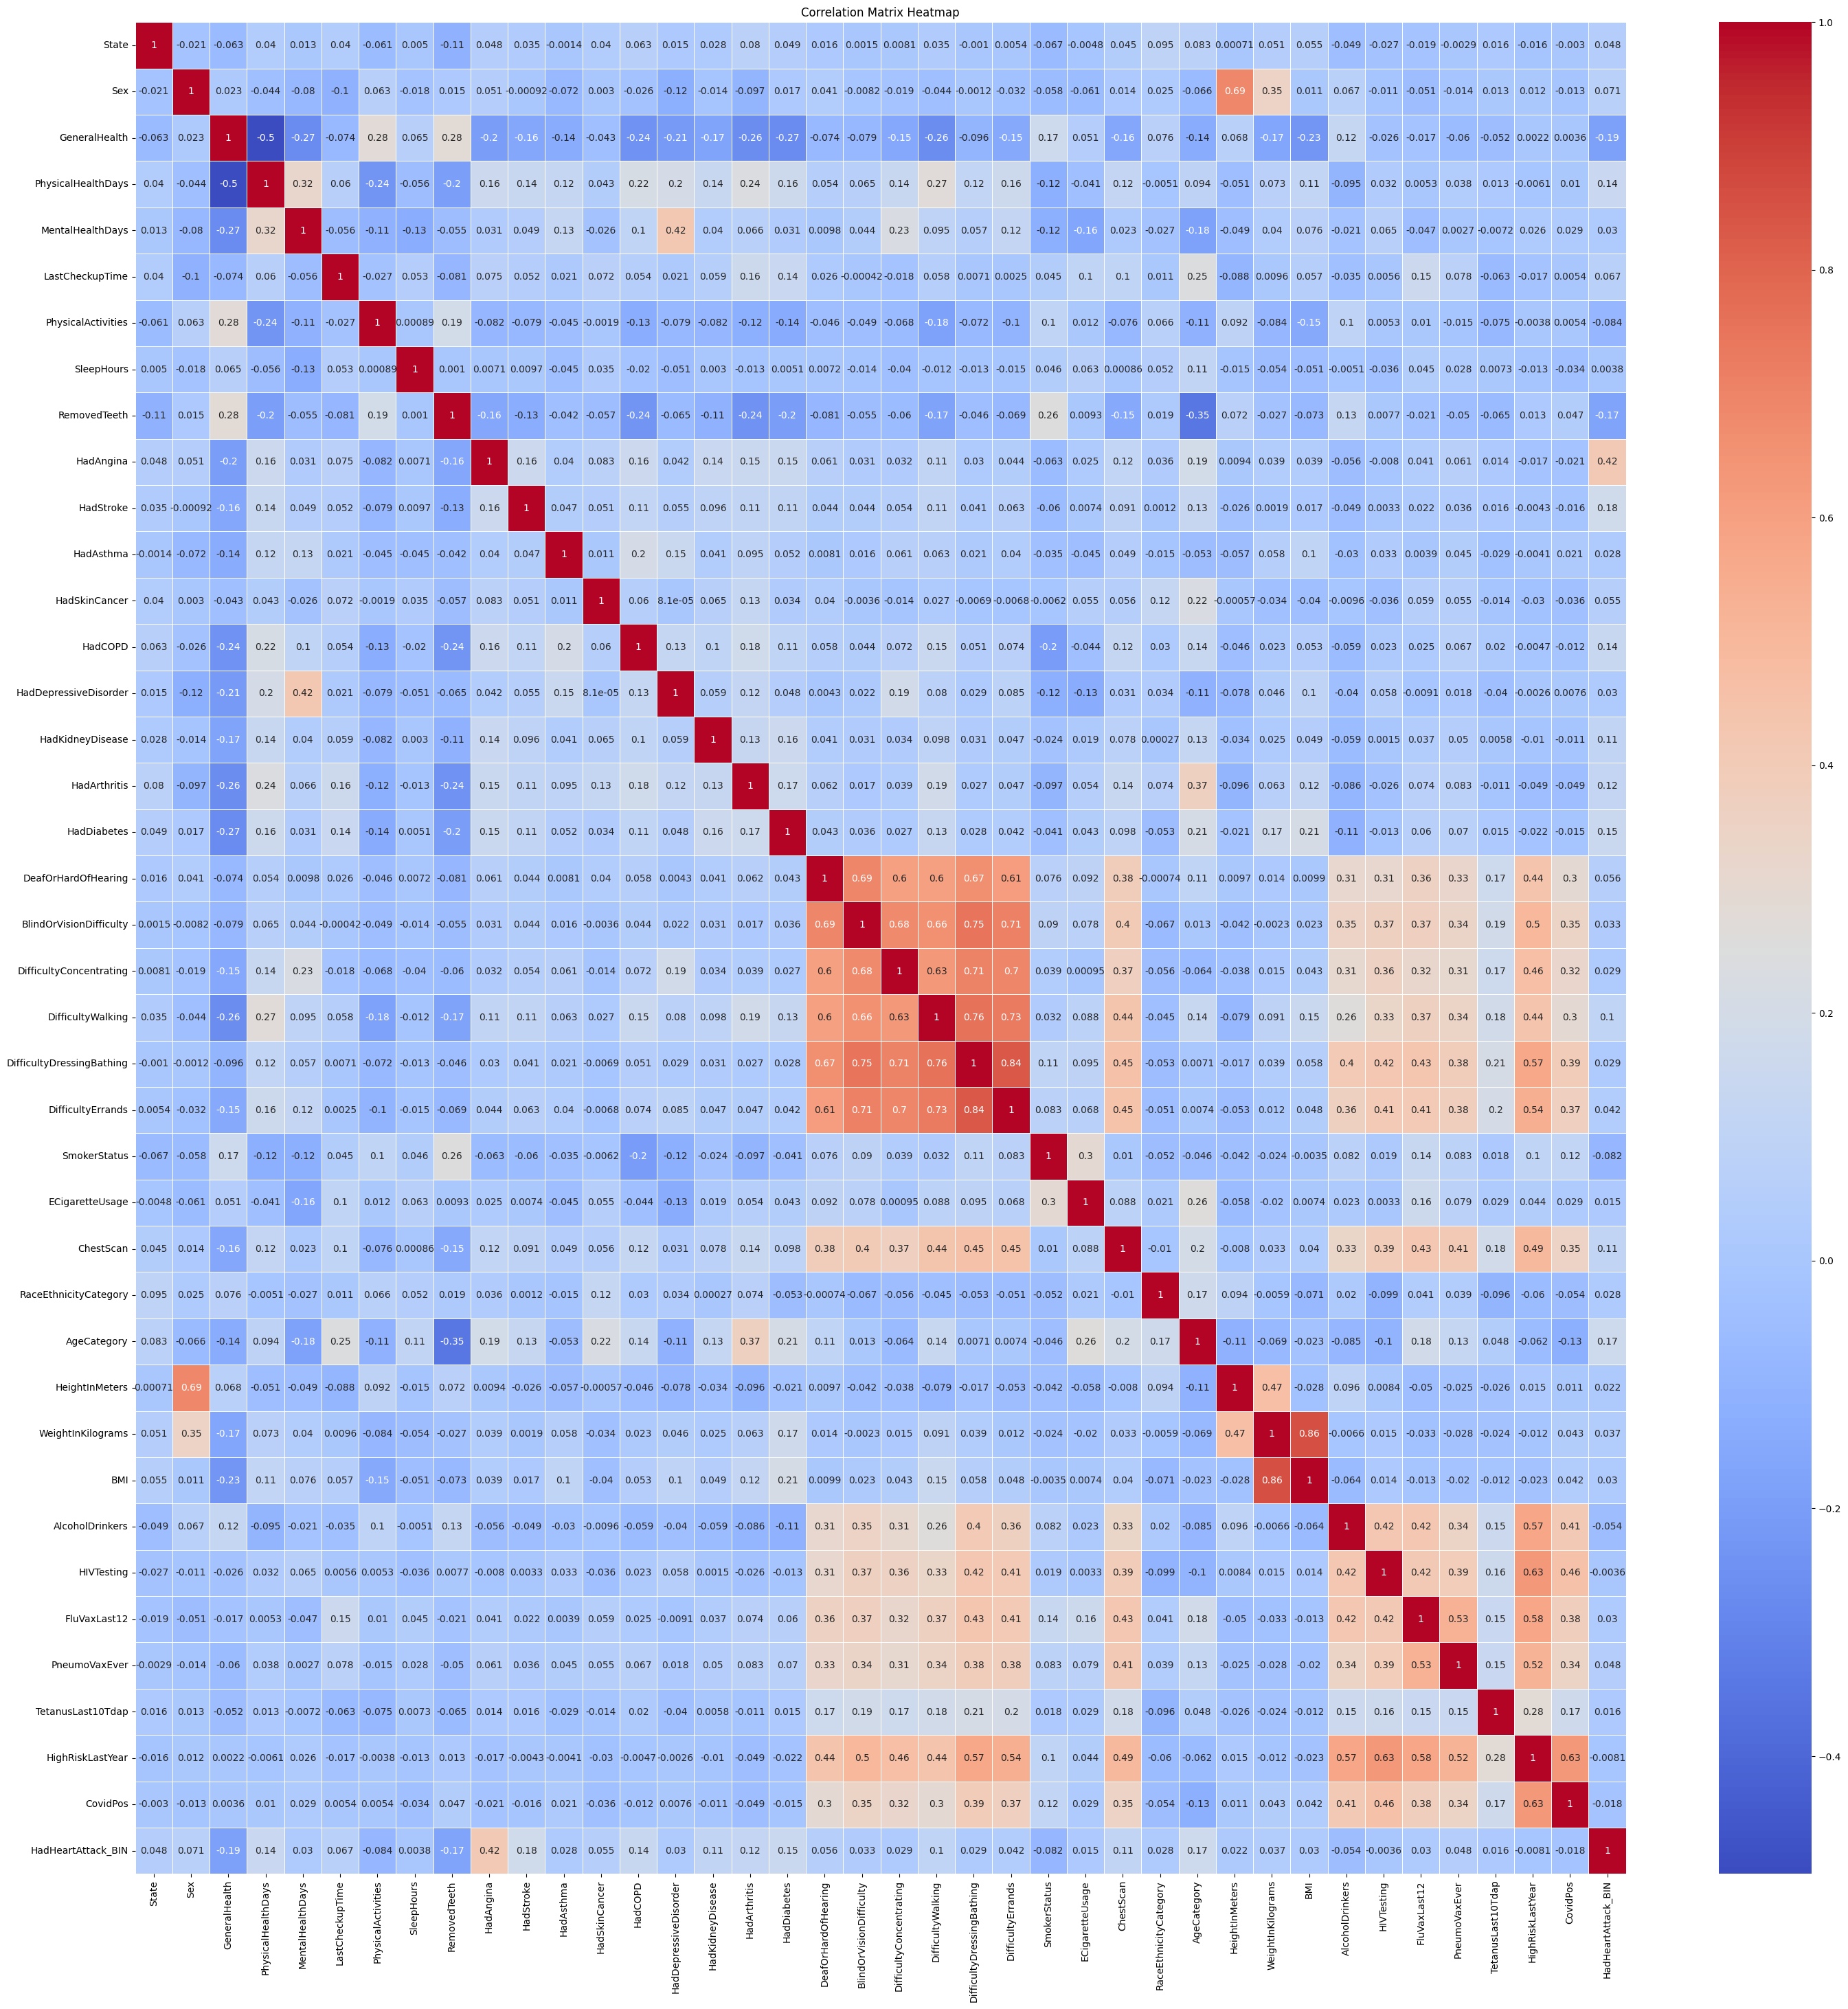

In [ ]:
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(35, 35))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
correlation_with_target = correlation_matrix['HadHeartAttack_BIN'].drop('HadHeartAttack_BIN')


sorted_correlation = correlation_with_target.abs().sort_values(ascending=False)


print("Features sorted by their correlation with HadHeartAttack_BIN:")
print(sorted_correlation)

Features sorted by their correlation with HadHeartAttack_BIN:
HadAngina                    0.415863
GeneralHealth                0.187264
HadStroke                    0.180887
RemovedTeeth                 0.171981
AgeCategory                  0.170662
HadDiabetes                  0.149799
PhysicalHealthDays           0.142547
HadCOPD                      0.137120
HadArthritis                 0.121199
HadKidneyDisease             0.110346
ChestScan                    0.108992
DifficultyWalking            0.102983
PhysicalActivities           0.084468
SmokerStatus                 0.082375
Sex                          0.071067
LastCheckupTime              0.067453
DeafOrHardOfHearing          0.056272
HadSkinCancer                0.054659
AlcoholDrinkers              0.053572
PneumoVaxEver                0.048457
State                        0.048358
DifficultyErrands            0.042182
WeightInKilograms            0.037354
BlindOrVisionDifficulty      0.033170
FluVaxLast12              

#By examining the thermal correlation matrix, we can conclude that we can remove the following parameters that have too little effect on our target variable and will only overload our model

In [ ]:
columns_to_keep = [
    'HadAngina',
    'GeneralHealth',
    'HadStroke',
    'RemovedTeeth',
    'AgeCategory',
    'HadDiabetes',
    'PhysicalHealthDays',
    'HadCOPD',
    'HadArthritis',
    'HadKidneyDisease',
    'ChestScan',
    'DifficultyWalking',
    'PhysicalActivities',
    'SmokerStatus',
    'Sex',
    'LastCheckupTime',
    'DeafOrHardOfHearing',
    'HadSkinCancer',
    'AlcoholDrinkers',
    'PneumoVaxEver',
    'State'
]


new_df = df[columns_to_keep]

In [ ]:
new_df

,HadAngina,GeneralHealth,HadStroke,RemovedTeeth,AgeCategory,HadDiabetes,PhysicalHealthDays,HadCOPD,HadArthritis,HadKidneyDisease,...,DifficultyWalking,PhysicalActivities,SmokerStatus,Sex,LastCheckupTime,DeafOrHardOfHearing,HadSkinCancer,AlcoholDrinkers,PneumoVaxEver,State
0,0,4,0,2,12,1.0,0.0,0,0,0,...,0,0,3.0,0,3,0,0,0,0,2.244880
1,0,5,0,2,12,0.0,0.0,0,0,0,...,0,0,3.0,0,2,0,1,0,0,2.244880
2,0,4,0,2,7,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,1,0,0,2.244880
3,0,5,0,2,13,0.0,0.0,0,1,0,...,0,1,1.0,0,3,0,0,0,1,2.244880
4,0,2,0,2,4,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,0,1,1,2.244880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,0,3,0,3,0,0.0,0.0,0,0,0,...,0,1,3.0,0,2,0,0,2,0,1.276018
442063,0,5,0,3,6,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,0,0,0,1.276018
442064,0,1,0,2,9,0.0,30.0,0,0,0,...,0,0,0.5,0,1,0,0,2,0,1.276018
442065,0,4,0,3,10,0.0,0.0,0,0,0,...,0,0,3.0,1,3,0,0,0,1,1.276018


In [ ]:
!pip install catboost

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 8.2 MB/s eta 0:00:00


In [ ]:

from sklearn.model_selection import GridSearchCV

X = df.drop('HadHeartAttack_BIN', axis=1)
y = df['HadHeartAttack_BIN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
nan_counts = df.isna().sum()
print(nan_counts)

State                            0
Sex                              0
GeneralHealth                    0
PhysicalHealthDays           10597
MentalHealthDays              8792
LastCheckupTime                  0
PhysicalActivities               0
SleepHours                    5196
RemovedTeeth                     0
HadAngina                        0
HadStroke                        0
HadAsthma                        0
HadSkinCancer                    0
HadCOPD                          0
HadDepressiveDisorder            0
HadKidneyDisease                 0
HadArthritis                     0
HadDiabetes                      0
DeafOrHardOfHearing              0
BlindOrVisionDifficulty          0
DifficultyConcentrating          0
DifficultyWalking                0
DifficultyDressingBathing        0
DifficultyErrands                0
SmokerStatus                     0
ECigaretteUsage                  0
ChestScan                        0
RaceEthnicityCategory            0
AgeCategory         

###We see that there are very few Nan values ​​and the only remaining ones are in the columns where there are binary answers. So we can't fill them out. Accordingly, they need to be removed, however, there are few of them, therefore, we can do it

In [ ]:
df= df.dropna()

##And now I will use different ways to deal with unbalanced classes

In [ ]:
X = df.drop('HadHeartAttack_BIN', axis=1)
y = df['HadHeartAttack_BIN']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
if isinstance(y_train, pd.Series):
    y_train = y_train.to_frame()


df_train = pd.concat([X_train, y_train], axis=1)

In [ ]:
y_train.value_counts(normalize=True)

HadHeartAttack_BIN
0                     0.943229
1                     0.056771
Name: proportion, dtype: float64

In [ ]:
df_train.shape

(301580, 40)

In [ ]:
df_train

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
240767,2.400701,0,4,0.0,0.0,3,1,8.0,3,0,...,54.43,24.24,1,1,1,1,3,0,0,0
440307,1.615470,1,4,0.0,0.0,3,0,7.0,3,0,...,68.04,20.34,0,1,1,0,4,1,2,0
53965,1.470192,0,5,0.0,0.0,3,1,6.0,3,0,...,55.34,20.94,1,0,0,0,4,0,0,0
279299,2.004587,1,1,22.0,17.0,2,1,14.0,3,0,...,102.06,27.39,1,2,2,2,4,2,3,0
114615,1.631298,0,2,30.0,10.0,3,0,9.0,3,0,...,53.07,20.73,0,0,0,1,3,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317957,1.844774,1,4,0.0,0.0,3,1,7.0,3,0,...,72.57,25.82,1,0,1,1,1,0,0,0
407457,1.523398,0,4,0.0,0.0,3,1,8.0,3,0,...,54.43,19.97,1,0,0,0,3,0,3,0
126833,1.843353,0,5,0.0,0.0,1,0,4.0,3,0,...,68.04,25.75,0,1,0,2,4,0,0,0
159898,1.734463,1,2,0.0,0.0,3,1,7.0,3,0,...,106.59,36.81,1,0,1,1,4,0,0,0


##1. Upsampling

In [ ]:

import pandas as pd
from sklearn.utils import resample



df_minority = df_train[df_train.HadHeartAttack_BIN == 1]
df_majority = df_train[df_train.HadHeartAttack_BIN == 0]

df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Дублирование примеров
                                 n_samples=len(df_majority), # Уравнивание количества
                                 random_state=123) # Фиксация случайного состояния для воспроизводимости

df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
df_upsampled.shape

(568918, 40)

In [ ]:
X_upsampled = df_upsampled.drop('HadHeartAttack_BIN', axis=1)
y_upsampled = df_upsampled['HadHeartAttack_BIN']


In [ ]:
y_upsampled.value_counts(normalize=True)

HadHeartAttack_BIN
0    0.5
1    0.5
Name: proportion, dtype: float64

##Now we have balanced classes

In [ ]:
df_upsampled.shape

(568918, 40)

##2.Downsampling

In [ ]:


df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=123)

df_downsampled = pd.concat([df_majority_downsampled, df_minority])

In [ ]:
X_downsampled = df_upsampled.drop('HadHeartAttack_BIN', axis=1)
y_downsampled = df_upsampled['HadHeartAttack_BIN']


In [ ]:
df_downsampled.shape

(34242, 40)

In [ ]:
y_downsampled.value_counts(normalize=True)

HadHeartAttack_BIN
0    0.5
1    0.5
Name: proportion, dtype: float64

##Now we have balanced classes

#Let's move on to training machine learning models

#1.CatBoostClassifier for train ds as X_upsampled and y_upsampled

In [ ]:

# Инициализация модели CatBoostClassifier
model = CatBoostClassifier(silent=True)


# Определение сетки параметров для grid search
param_grid = {
    'iterations': [100, 200],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [ 7, 9]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)


# обуч с кросс-валидацией
grid_search.fit(X_upsampled, y_upsampled)

# Получение лучших параметров и наилучшего результата
best_params = grid_search.best_params_

best_score = grid_search.best_score_

print("Best parameters found: ", best_params)
print("Best accuracy found: ", best_score)




Best parameters found:  {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.1}
Best accuracy found:  0.8392808797258685


In [ ]:
!pip install shap

CatBoost Accuracy on test data: 0.8411852087643907
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     71116
           1       0.23      0.77      0.36      4280

    accuracy                           0.84     75396
   macro avg       0.61      0.81      0.63     75396
weighted avg       0.94      0.84      0.88     75396



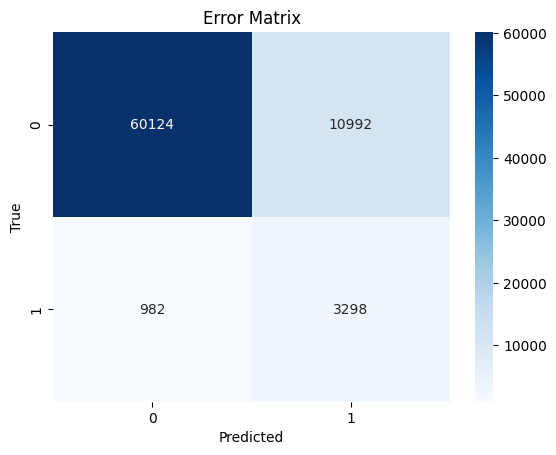

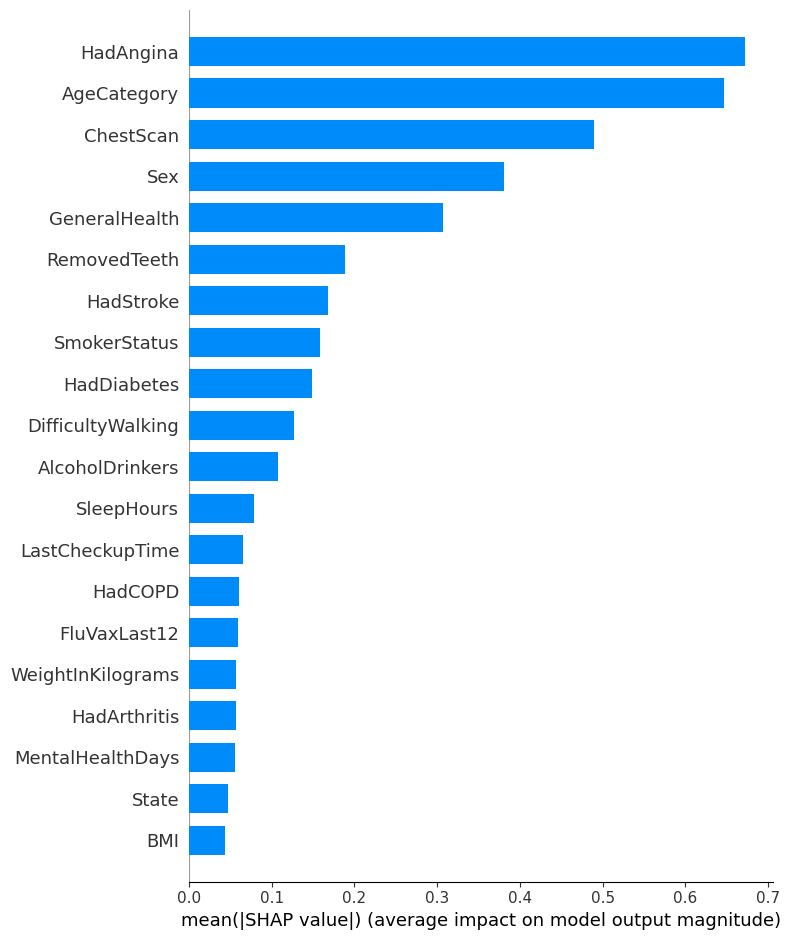

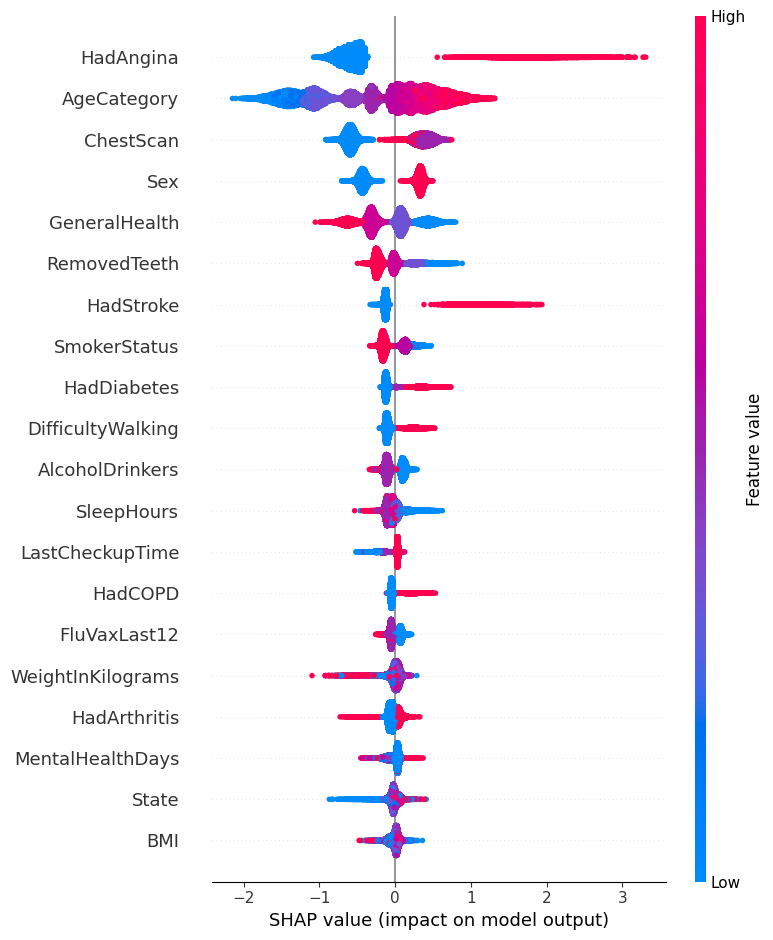

Количество ошибок: 11974
Примеры ошибочных предсказаний:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
56611   1.671159    0              2                25.0               2.0   
21105   2.789159    1              2                30.0               5.0   
360878  1.387030    1              1                30.0               0.0   
379350  1.831811    1              2                 0.0               0.0   
109672  2.019756    0              3                 1.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
56611                 3                   0         5.0             0   
21105                 3                   0         4.0             0   
360878                1                   0         4.0             2   
379350                3                   1         6.0             2   
109672                3                   1         7.0             3   

        HadAngina  ...  HeightInMet

In [ ]:

import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap

model_cat = CatBoostClassifier(depth=8, iterations=200, l2_leaf_reg=7, learning_rate=0.1, silent=True)
model_cat.fit(X_upsampled, y_upsampled)

y_pred_cat = model_cat.predict(X_test)


print(f'CatBoost Accuracy on test data: {accuracy_score(y_test, y_pred_cat)}')
print(classification_report(y_test, y_pred_cat))

conf_matrix = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

# Анализ ошибок
errors = X_test_upsampled[(y_pred_cat != y_test)]
print(f'Количество ошибок: {len(errors)}')
print("Примеры ошибочных предсказаний:")
print(errors.head())

#2. DummyClissifer for train ds as X_upsampled and y_upsampled

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_upsampled, y_upsampled)
dummy_y_pred = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_y_pred)
print("Accuracy of sklearn DummyClassifier: ", dummy_accuracy)






Accuracy of sklearn DummyClassifier:  0.9432330627619502


Dummy Accuracy on test data: 0.9432330627619502
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     71116
           1       0.00      0.00      0.00      4280

    accuracy                           0.94     75396
   macro avg       0.47      0.50      0.49     75396
weighted avg       0.89      0.94      0.92     75396



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


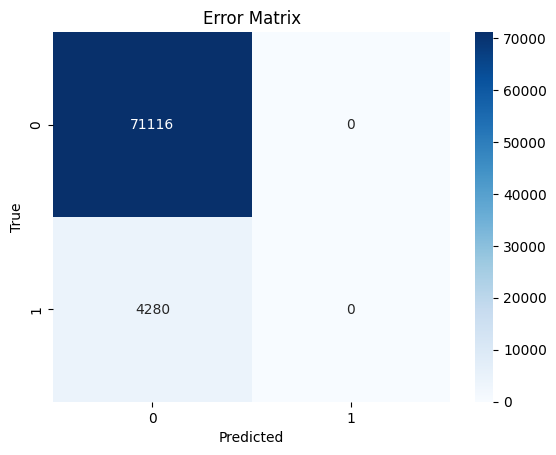

Number of mistakes: 4280
Examples of erroneous predictions:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
242729  2.400701    1              4                 5.0               0.0   
149243  2.281618    1              2                15.0              20.0   
200425  1.448515    1              2                20.0               2.0   
102291  1.325292    0              2                 2.0              10.0   
235519  2.004755    1              2                 0.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
242729                3                   1         6.0             3   
149243                3                   1         4.0             0   
200425                3                   1         5.0             3   
102291                3                   0         7.0             0   
235519                3                   1         7.0             1   

        HadAngina  ...  HeightIn

In [ ]:

print(f'Dummy Accuracy on test data: {accuracy_score(y_test, dummy_y_pred)}')
print(classification_report(y_test, dummy_y_pred))

conf_matrix = confusion_matrix(y_test, dummy_y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()


# Анализ ошибок
errors = X_test_upsampled[(dummy_y_pred != y_test)]
print(f'Number of mistakes: {len(errors)}')
print("Examples of erroneous predictions:")
print(errors.head())

#3. Logistic Regression for train ds as X_upsampled and y_upsampled

In [ ]:

param_grid_l_r = {
    'C': [0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear']
}

grid_search_l_r = GridSearchCV(LogisticRegression(), param_grid_l_r, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_l_r.fit(X_upsampled, y_upsampled)

print(f'Best params: {grid_search_l_r.best_params_}')
print(f'Best cross-validation accuracy: {grid_search_l_r.best_score_}')

best_model_l_r = grid_search_l_r.best_estimator_



Best params: {'C': 0.1, 'solver': 'newton-cg'}
Best cross-validation accuracy: 0.8028819602986317


In [ ]:
best_params_l_r = {'C': 0.1, 'solver': 'newton-cg'}
model_l_r = LogisticRegression(**best_params_l_r )
model_l_r.fit(X_upsampled, y_upsampled)

LogisticRegression(C=0.1, solver='newton-cg')

Accuracy on test data: 0.8352299856756327
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     71116
           1       0.22      0.78      0.35      4280

    accuracy                           0.84     75396
   macro avg       0.60      0.81      0.63     75396
weighted avg       0.94      0.84      0.87     75396



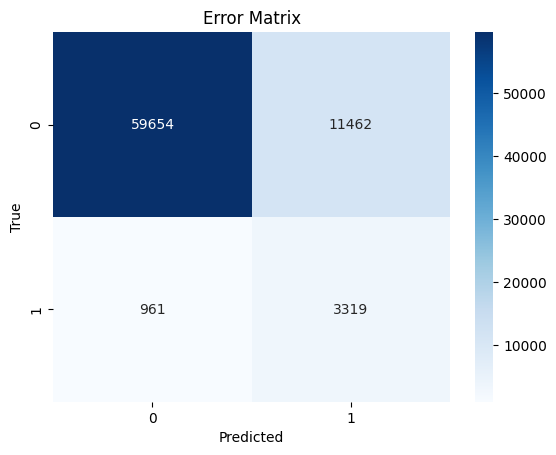

In [ ]:
y_pred_l_r = model_l_r.predict(X_test)
print(f'Accuracy on test data: {accuracy_score(y_test, y_pred_l_r)}')
print(classification_report(y_test, y_pred_l_r))

conf_matrix = confusion_matrix(y_test, y_pred_l_r)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

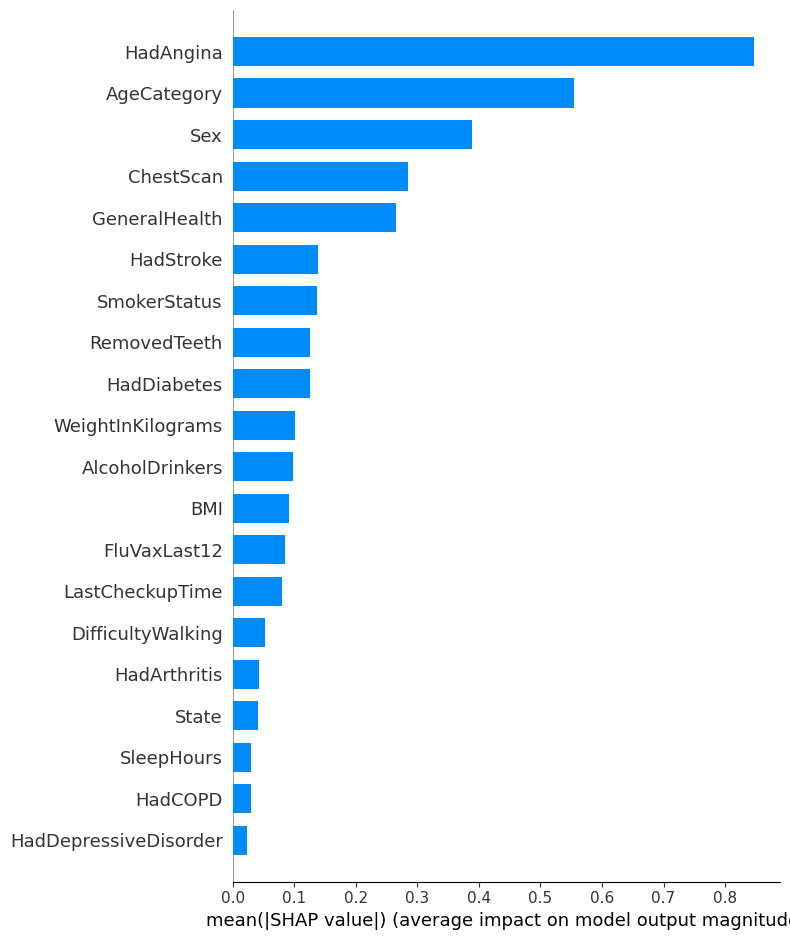

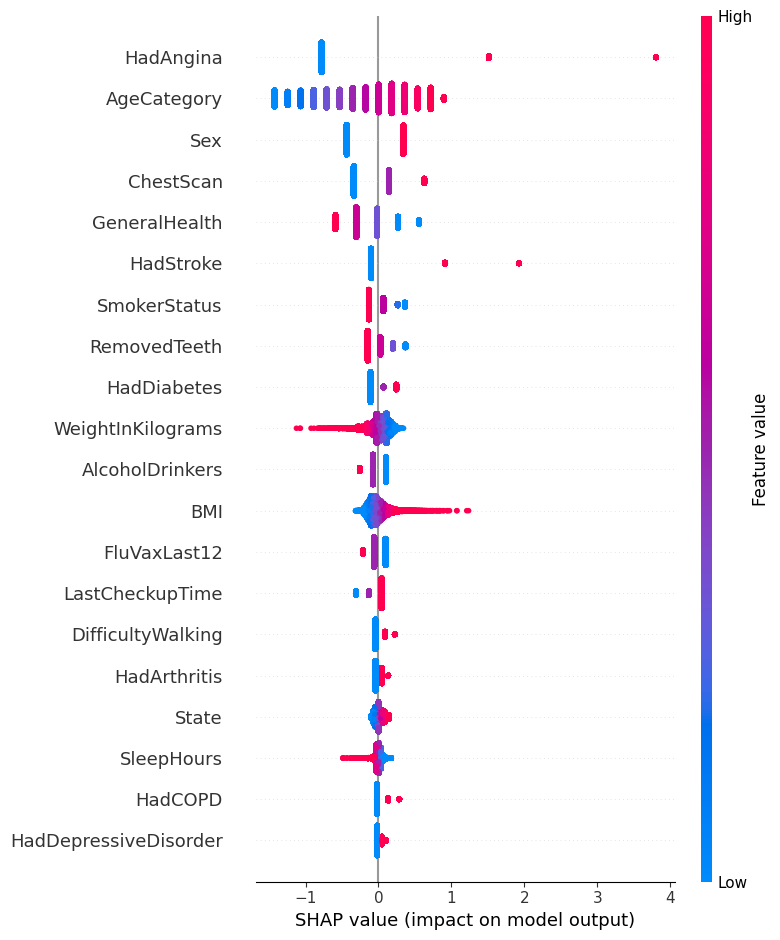

In [ ]:


explainer = shap.Explainer(model_l_r, X_upsampled)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


#4.LightGBM for df_upsampled

In [ ]:
from lightgbm import LGBMClassifier


param_grid_LGBM = {
    'n_estimators': [ 100, 200],
    'learning_rate': [ 0.1, 0.2],
    'max_depth': [ 6, 8]
}

# Инициализация и выполнение GridSearchCV
grid_search = GridSearchCV(LGBMClassifier(), param_grid_LGBM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_upsampled, y_upsampled)


'''
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
lgbm_model.fit(X_train, y_train)
'''
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test_upsampled)
print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 284459, number of negative: 284459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.330717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 847
[LightGBM] [Info] Number of data points in the train set: 568918, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
LightGBM Accuracy on test data: 0.843068597803597
              precision    recall  f1-score   support



In [ ]:
print(grid_search.best_params_)

{'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}


LightGBM Accuracy on test data: 0.843068597803597
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     71116
           1       0.23      0.75      0.35      4280

    accuracy                           0.84     75396
   macro avg       0.61      0.80      0.63     75396
weighted avg       0.94      0.84      0.88     75396



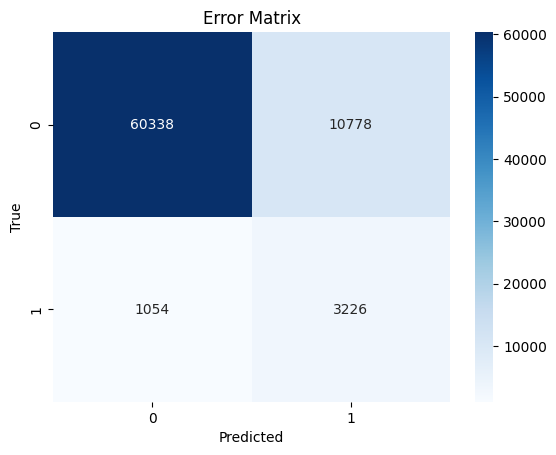

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


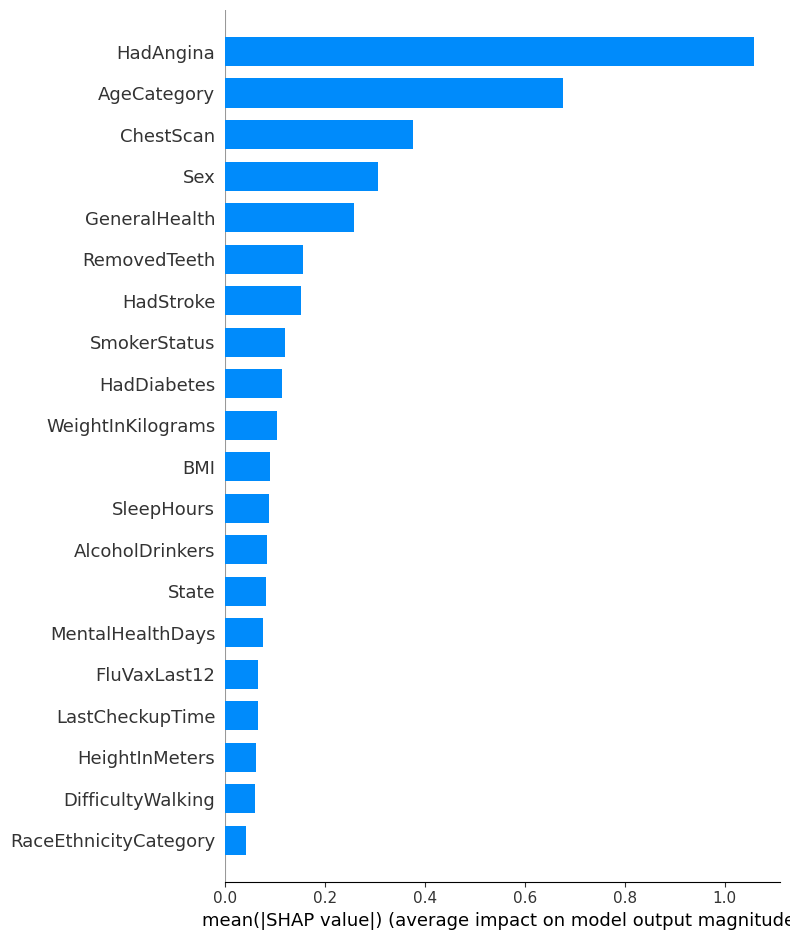

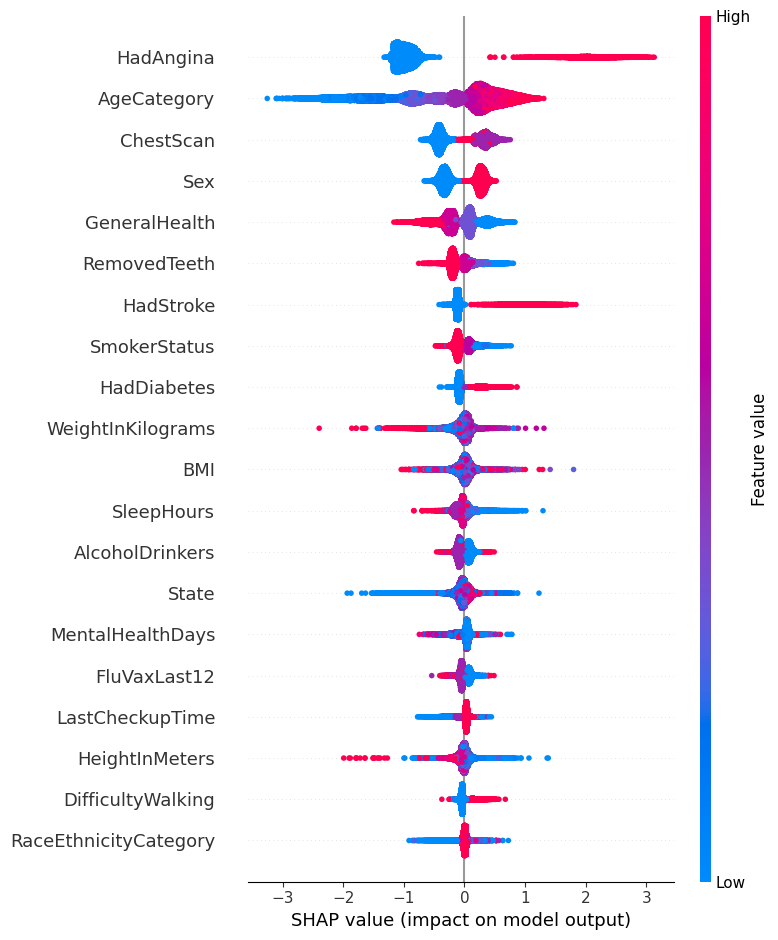

In [ ]:

print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)



#1.CatBoostClassifier for train ds as X_downsampled and y_downsampled

In [ ]:

# Инициализация модели CatBoostClassifier
model = CatBoostClassifier(silent=True)


# Определение сетки параметров для grid search
param_grid = {
    'iterations': [100, 200],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [ 7, 9]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)


# обуч с кросс-валидацией
grid_search.fit(X_downsampled, y_downsampled)

# Получение лучших параметров и наилучшего результата
best_params = grid_search.best_params_

best_score = grid_search.best_score_

print("Best parameters found: ", best_params)
print("Best accuracy found: ", best_score)




Best parameters found:  {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.1}
Best accuracy found:  0.8392808797258685


CatBoost Accuracy on test data: 0.8411852087643907
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     71116
           1       0.23      0.77      0.36      4280

    accuracy                           0.84     75396
   macro avg       0.61      0.81      0.63     75396
weighted avg       0.94      0.84      0.88     75396



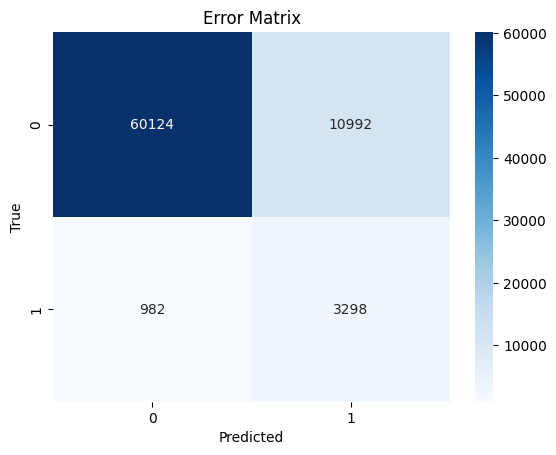

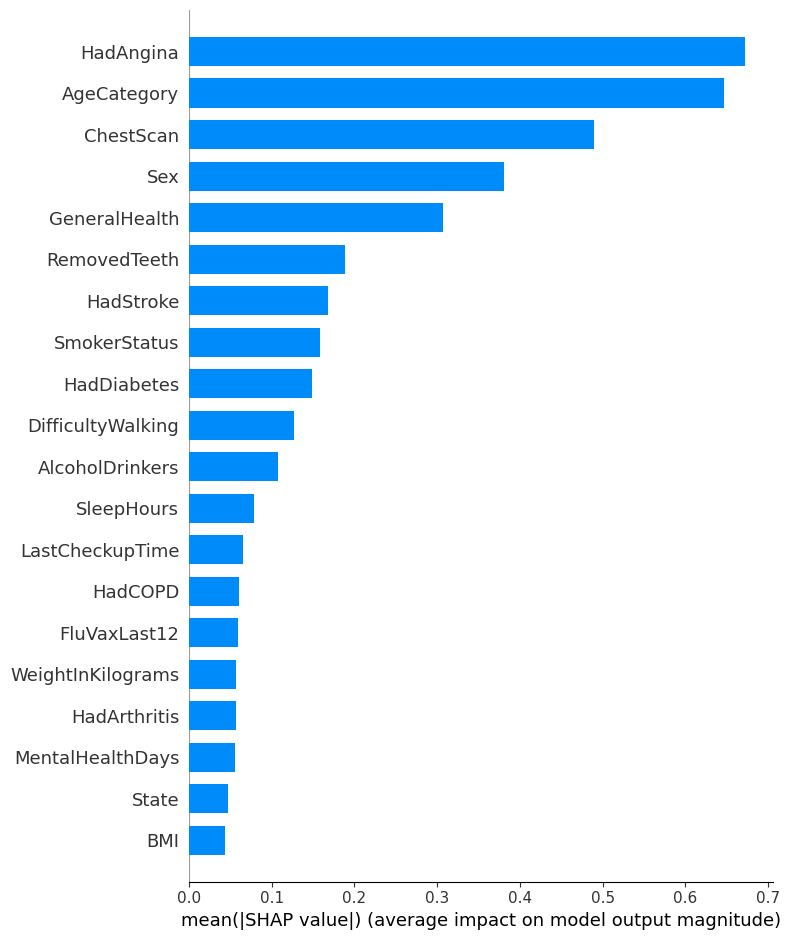

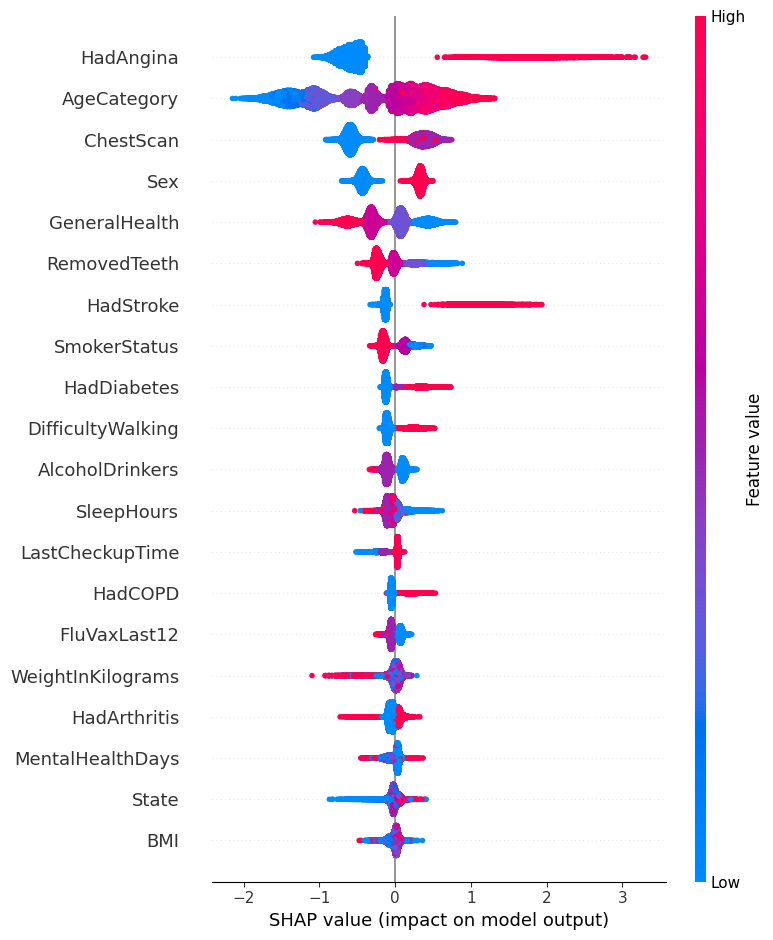

Количество ошибок: 11974
Примеры ошибочных предсказаний:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
56611   1.671159    0              2                25.0               2.0   
21105   2.789159    1              2                30.0               5.0   
360878  1.387030    1              1                30.0               0.0   
379350  1.831811    1              2                 0.0               0.0   
109672  2.019756    0              3                 1.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
56611                 3                   0         5.0             0   
21105                 3                   0         4.0             0   
360878                1                   0         4.0             2   
379350                3                   1         6.0             2   
109672                3                   1         7.0             3   

        HadAngina  ...  HeightInMet

In [ ]:


model_cat = CatBoostClassifier(depth=8, iterations=200, l2_leaf_reg=7, learning_rate=0.1, silent=True)
model_cat.fit(X_downsampled, y_downsampled)

y_pred_cat = model_cat.predict(X_test)
print(f'CatBoost Accuracy on test data: {accuracy_score(y_test, y_pred_cat)}')
print(classification_report(y_test, y_pred_cat))

conf_matrix = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

# Анализ ошибок
errors = X_test_upsampled[(y_pred_cat != y_test)]
print(f'Количество ошибок: {len(errors)}')
print("Примеры ошибочных предсказаний:")
print(errors.head())

#2. DummyClissifer for train ds as X_downsampled and y_downsampled

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_downsampled, y_downsampled)
dummy_y_pred = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_y_pred)
print("Accuracy of sklearn DummyClassifier: ", dummy_accuracy)






Accuracy of sklearn DummyClassifier:  0.9432330627619502


Dummy Accuracy on test data: 0.9432330627619502
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     71116
           1       0.00      0.00      0.00      4280

    accuracy                           0.94     75396
   macro avg       0.47      0.50      0.49     75396
weighted avg       0.89      0.94      0.92     75396



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


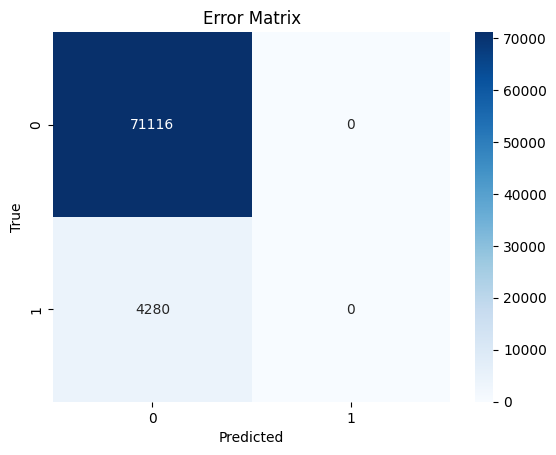

Number of mistakes: 4280
Examples of erroneous predictions:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
242729  2.400701    1              4                 5.0               0.0   
149243  2.281618    1              2                15.0              20.0   
200425  1.448515    1              2                20.0               2.0   
102291  1.325292    0              2                 2.0              10.0   
235519  2.004755    1              2                 0.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
242729                3                   1         6.0             3   
149243                3                   1         4.0             0   
200425                3                   1         5.0             3   
102291                3                   0         7.0             0   
235519                3                   1         7.0             1   

        HadAngina  ...  HeightIn

In [ ]:

print(f'Dummy Accuracy on test data: {accuracy_score(y_test, dummy_y_pred)}')
print(classification_report(y_test, dummy_y_pred))

conf_matrix = confusion_matrix(y_test, dummy_y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()


# Анализ ошибок
errors = X_test_downsampled[(dummy_y_pred != y_test)]
print(f'Number of mistakes: {len(errors)}')
print("Examples of erroneous predictions:")
print(errors.head())

#3. Logistic Regression for train ds as X_downsampled and y_downsampled

In [ ]:
#для данной модели буду использовать те же самые
# гиперпараметры, которые были и в модели Logistic Regression для df_upsampled
best_params_l_r = {'C': 0.1, 'solver': 'newton-cg'}
model_l_r = LogisticRegression(**best_params_l_r )
model_l_r.fit(X_downsampled, y_downsampled)

LogisticRegression(C=0.1, solver='newton-cg')

Accuracy on test data: 0.8352299856756327
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     71116
           1       0.22      0.78      0.35      4280

    accuracy                           0.84     75396
   macro avg       0.60      0.81      0.63     75396
weighted avg       0.94      0.84      0.87     75396



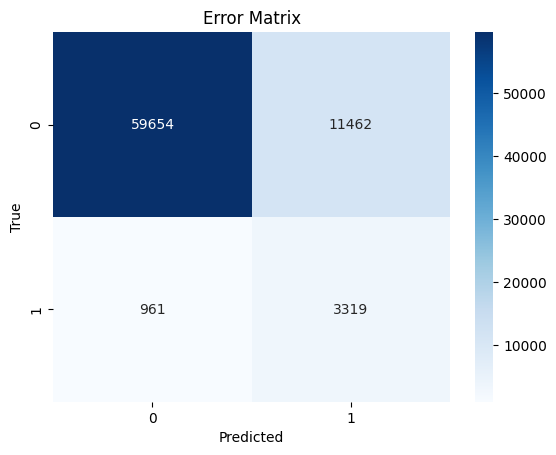

In [ ]:
y_pred_l_r = model_l_r.predict(X_test)
print(f'Accuracy on test data: {accuracy_score(y_test, y_pred_l_r)}')
print(classification_report(y_test, y_pred_l_r))

conf_matrix = confusion_matrix(y_test, y_pred_l_r)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

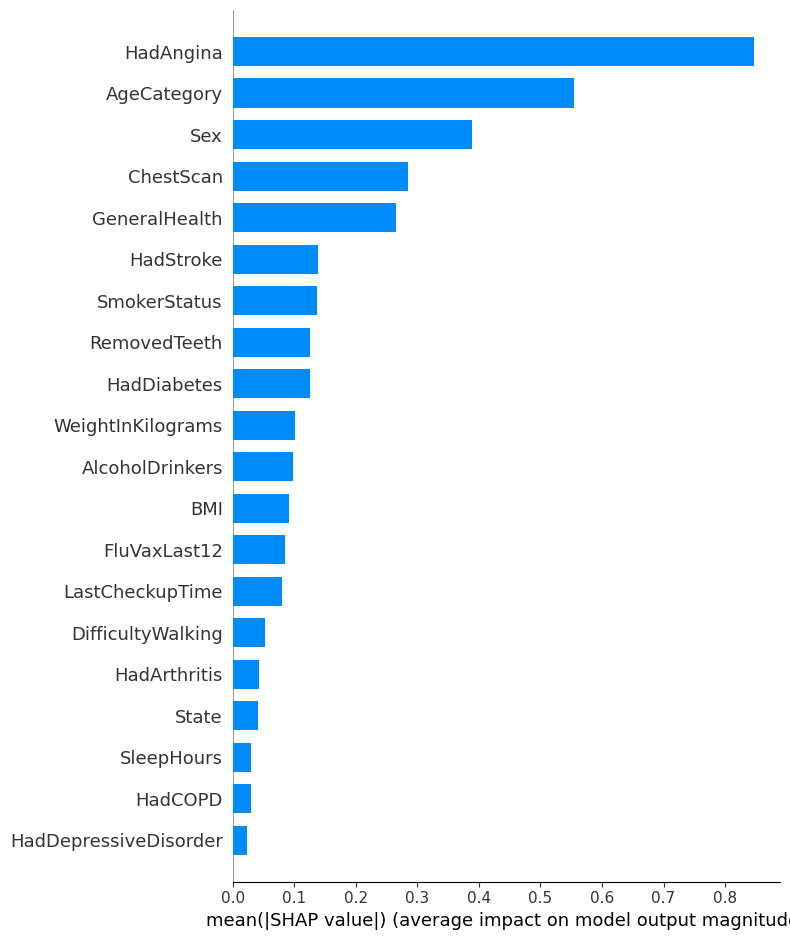

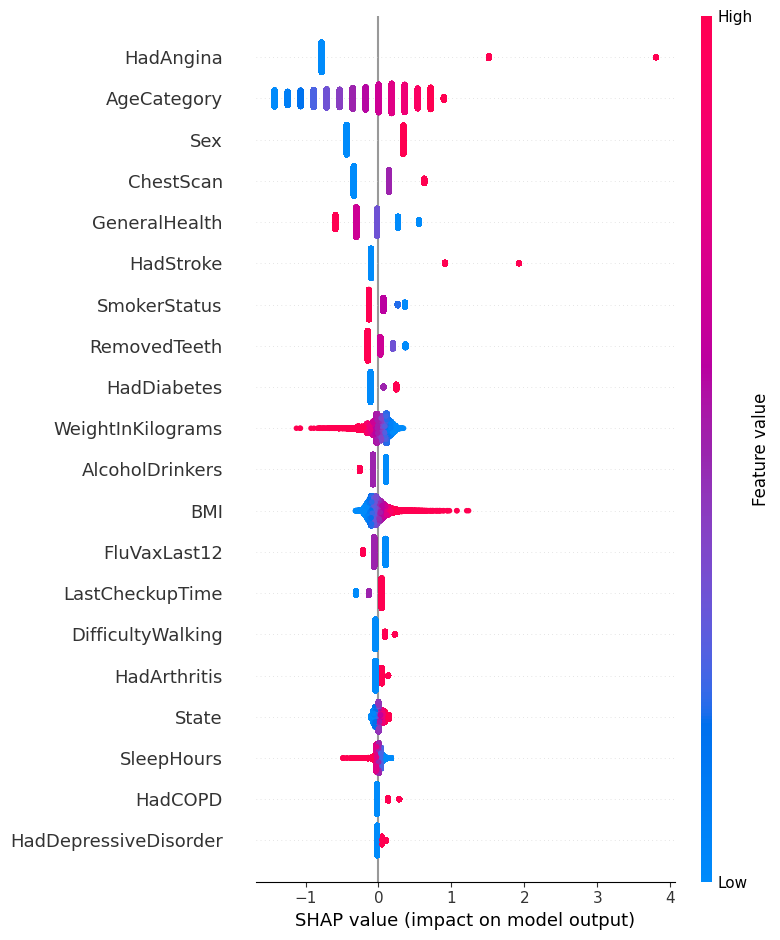

In [ ]:


explainer = shap.Explainer(model_l_r, X_downsampled)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


#4.LightGBM for train ds as X_downsampled and y_downsampled

In [ ]:
from lightgbm import LGBMClassifier


param_grid_LGBM = {
    'n_estimators': [ 100, 200],
    'learning_rate': [ 0.1, 0.2],
    'max_depth': [ 6, 8]
}

# Инициализация и выполнение GridSearchCV
grid_search = GridSearchCV(LGBMClassifier(), param_grid_LGBM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


'''
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
lgbm_model.fit(X_train, y_train)
'''
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)
print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:99: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 17121, number of negative: 284459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.139955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 853
[LightGBM] [Info] Number of data points in the train set: 301580, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.056771 -> initscore=-2.810283
[LightGBM] [Info] Start training from score -2.810283
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
LightGBM Accuracy on test data: 0.947729322510478
 

In [ ]:
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


LightGBM Accuracy on test data: 0.947729322510478
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     71116
           1       0.60      0.24      0.34      4280

    accuracy                           0.95     75396
   macro avg       0.78      0.61      0.66     75396
weighted avg       0.94      0.95      0.94     75396



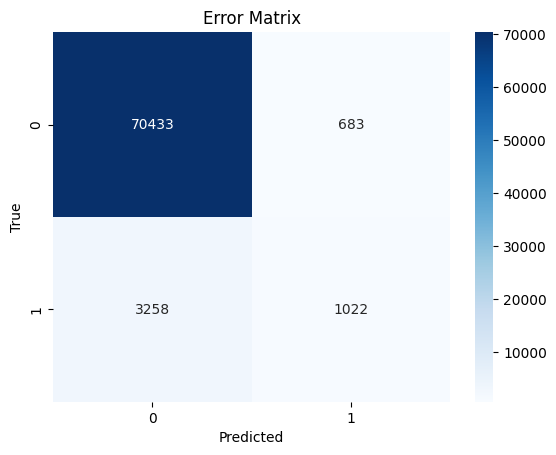

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


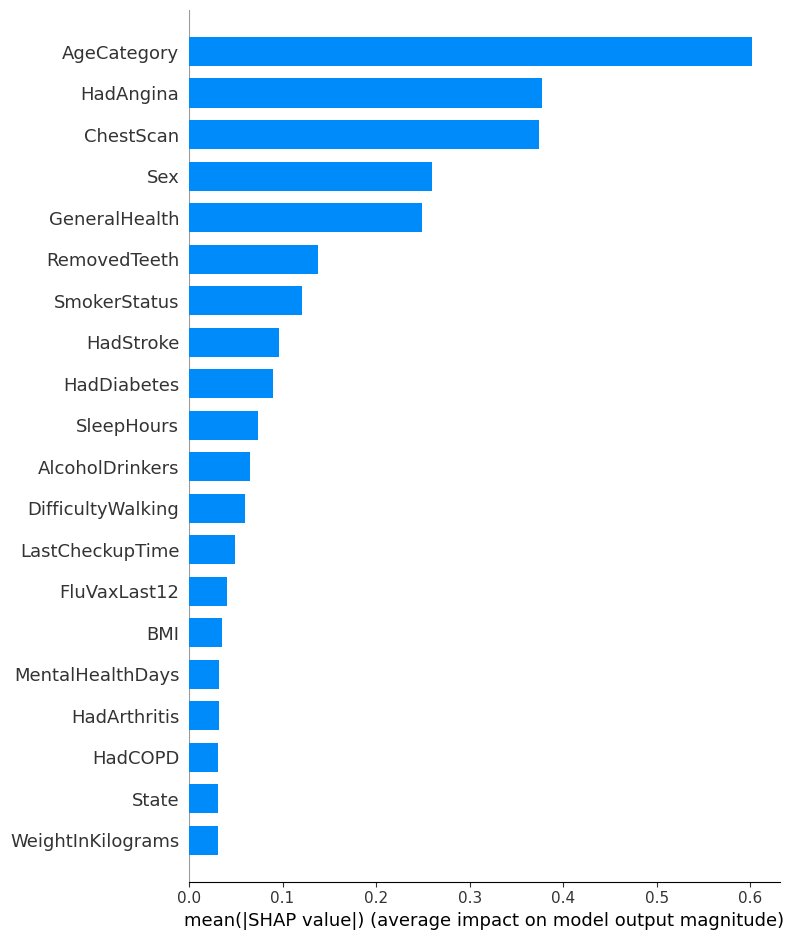

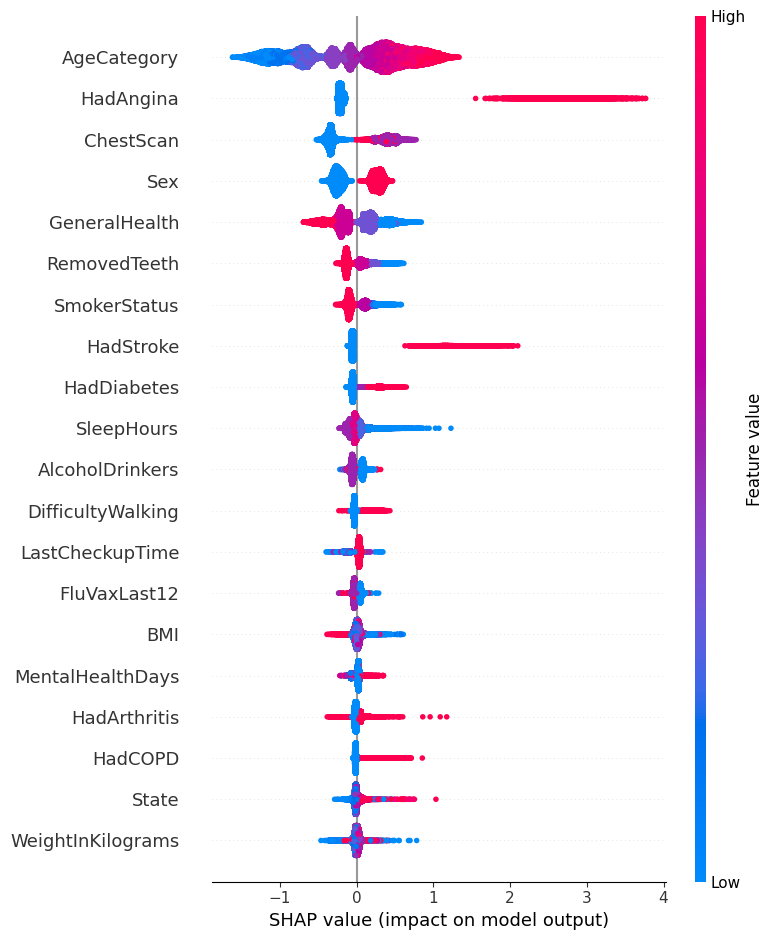

Количество ошибок: 3941
Примеры ошибочных предсказаний:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
242729  2.400701    1              4                 5.0               0.0   
21105   2.789159    1              2                30.0               5.0   
149243  2.281618    1              2                15.0              20.0   
260553  1.532204    0              4                 5.0               0.0   
406679  1.523398    0              1                29.0              28.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
242729                3                   1         6.0             3   
21105                 3                   0         4.0             0   
149243                3                   1         4.0             0   
260553                3                   0         8.0             2   
406679                3                   0         3.0             1   

        HadAngina  ...  HeightInMete

In [ ]:

print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

# Анализ ошибок
errors = X_test[(y_pred != y_test)]
print(f'Количество ошибок: {len(errors)}')
print("Примеры ошибочных предсказаний:")
print(errors.head())

#**And now I will work with machine learning models where there is a custom parameter class_weights**

###for downsampled dataset

**LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

from sklearn.metrics import classification_report


model_log_r = LogisticRegression(class_weight='balanced')
model_log_r.fit(X_downsampled, y_downsampled)


y_pred = model_log_r.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.98      0.86      0.92     71116
           1       0.24      0.71      0.35      4280

    accuracy                           0.85     75396
   macro avg       0.61      0.79      0.64     75396
weighted avg       0.94      0.85      0.89     75396



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**RandomForestClassifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model_r_f = RandomForestClassifier(class_weight='balanced')
model_r_f.fit(X_downsampled, y_downsampled)


y_pred = model_r_f.predict(X_test)
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     71116
           1       0.00      0.00      0.00      4280

    accuracy                           0.94     75396
   macro avg       0.47      0.50      0.49     75396
weighted avg       0.89      0.94      0.92     75396



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


###for upsampled dataset

**LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

from sklearn.metrics import classification_report


model_log_r = LogisticRegression(class_weight='balanced')
model_log_r.fit(X_upsampled, y_upsampled)


y_pred = model_log_r.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.98      0.86      0.92     71116
           1       0.24      0.71      0.35      4280

    accuracy                           0.85     75396
   macro avg       0.61      0.79      0.64     75396
weighted avg       0.94      0.85      0.89     75396



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**RandomForestClassifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model_r_f = RandomForestClassifier(class_weight='balanced')
model_r_f.fit(X_upsampled, y_upsampled)


y_pred = model_r_f.predict(X_test)
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     71116
           1       0.00      0.00      0.00      4280

    accuracy                           0.94     75396
   macro avg       0.47      0.50      0.49     75396
weighted avg       0.89      0.94      0.92     75396



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#Learning curves

##For upsampling method

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")


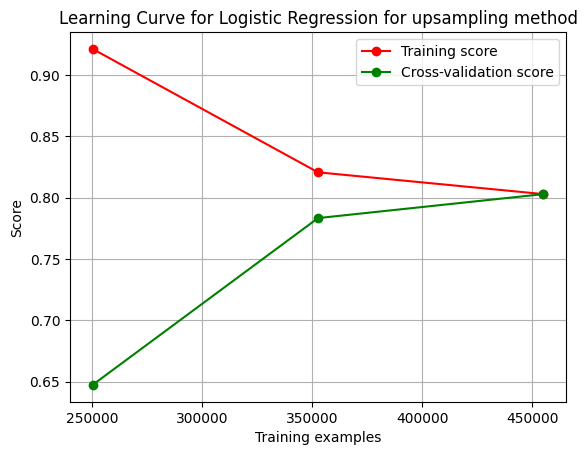

0:	learn: 0.5578167	total: 145ms	remaining: 28.8s
1:	learn: 0.4676506	total: 306ms	remaining: 30.3s
2:	learn: 0.3987663	total: 480ms	remaining: 31.5s
3:	learn: 0.3495121	total: 602ms	remaining: 29.5s
4:	learn: 0.3157660	total: 779ms	remaining: 30.4s
5:	learn: 0.2896239	total: 965ms	remaining: 31.2s
6:	learn: 0.2705637	total: 1.13s	remaining: 31.1s
7:	learn: 0.2568070	total: 1.29s	remaining: 31.1s
8:	learn: 0.2446131	total: 1.49s	remaining: 31.6s
9:	learn: 0.2352096	total: 1.67s	remaining: 31.8s
10:	learn: 0.2272183	total: 1.86s	remaining: 31.9s
11:	learn: 0.2217876	total: 2.03s	remaining: 31.8s
12:	learn: 0.2174119	total: 2.2s	remaining: 31.7s
13:	learn: 0.2143476	total: 2.36s	remaining: 31.4s
14:	learn: 0.2117052	total: 2.55s	remaining: 31.4s
15:	learn: 0.2089622	total: 2.75s	remaining: 31.7s
16:	learn: 0.2067115	total: 2.94s	remaining: 31.7s
17:	learn: 0.2055064	total: 3.07s	remaining: 31.1s
18:	learn: 0.2039104	total: 3.26s	remaining: 31.1s
19:	learn: 0.2029357	total: 3.46s	remainin

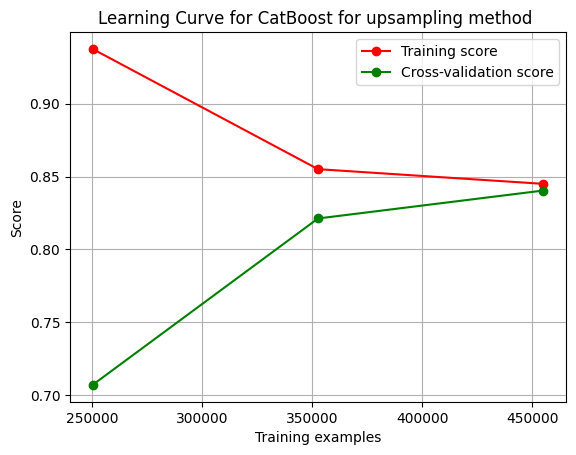

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 45513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 45513, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped trainin

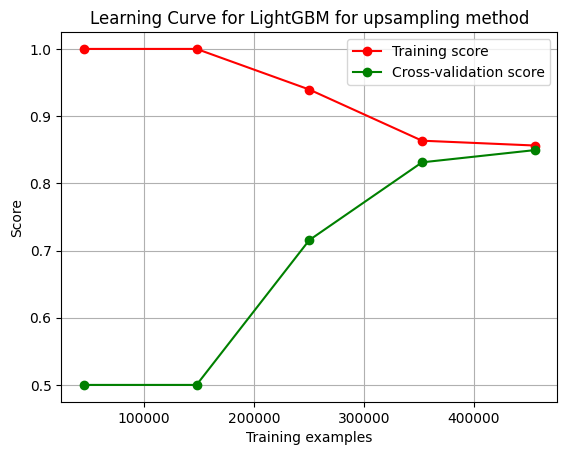

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()

    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

plot_learning_curve(LogisticRegression(**{'C': 0.1, 'solver': 'newton-cg'}), "Learning Curve for Logistic Regression for upsampling method", X_upsampled, y_upsampled, cv=5)
plt.show()

plot_learning_curve(CatBoostClassifier(**{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.1}), "Learning Curve for CatBoost for upsampling method ", X_upsampled, y_upsampled, cv=5)
plt.show()
plot_learning_curve(LGBMClassifier(**{'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}), "Learning Curve for LightGBM for upsampling method", X_upsampled, y_upsampled, cv=5)
plt.show()


#**Graph Analysis:**

**Learning Curve for Logistic Regression for upsampling method:**

**Training curve (red)**:

Starts at around 0.935, indicating good learning from the training data with some overfitting.

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at approximately 0.80.

**Cross-validation curve (green):**

The start is at a level of about 0.65, which indicates a low generalization ability of the model with a small amount of data.
As the number of training examples increases, the accuracy on cross-validation data increases significantly.
The curve stabilizes around the 0.80 level, indicating that the generalization ability of the model improves with more data.




**Learning Curve for CatBoost for upsampling method**

**Training curve (red):**

Starts at around 0.94, indicating good learning from the training data with some overfitting.

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at approximately 0.85.

**Cross-validation curve (green):**

The start is at a level of about 0.705, which indicates a low generalization ability of the model with a small amount of data.

As the number of training examples increases, the accuracy on cross-validation data increases significantly.

The curve stabilizes around the 0.85 level, indicating that the generalization ability of the model improves with more data.

**Learning Curve for LightGBM for upsampling method:**

**Training curve (red)**:

Starts at level 1, indicating perfect learning from the training data (overfitting).

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at about 0.85, indicating that the model improves with more data.

**Cross-validation curve (green)**:

Starts at level 0.5, which indicates poor generalization ability of the model with a small amount of data.
As the number of training examples increases, the accuracy on cross-validation data increases significantly.

As the number of training examples increases, the accuracy on cross-validation data increases significantly.

The curve stabilizes around the level of 0.85, which indicates a good generalization ability of the model as the data increases.

##For downsampling method

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")


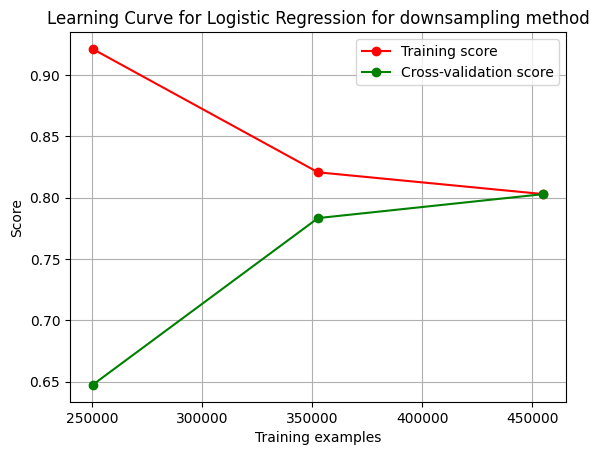

0:	learn: 0.5578167	total: 88.8ms	remaining: 17.7s
1:	learn: 0.4676506	total: 178ms	remaining: 17.6s
2:	learn: 0.3987663	total: 263ms	remaining: 17.3s
3:	learn: 0.3495121	total: 347ms	remaining: 17s
4:	learn: 0.3157660	total: 436ms	remaining: 17s
5:	learn: 0.2896239	total: 526ms	remaining: 17s
6:	learn: 0.2705637	total: 631ms	remaining: 17.4s
7:	learn: 0.2568070	total: 724ms	remaining: 17.4s
8:	learn: 0.2446131	total: 808ms	remaining: 17.1s
9:	learn: 0.2352096	total: 900ms	remaining: 17.1s
10:	learn: 0.2272183	total: 992ms	remaining: 17s
11:	learn: 0.2217876	total: 1.08s	remaining: 16.9s
12:	learn: 0.2174119	total: 1.16s	remaining: 16.7s
13:	learn: 0.2143476	total: 1.24s	remaining: 16.5s
14:	learn: 0.2117052	total: 1.33s	remaining: 16.4s
15:	learn: 0.2089622	total: 1.43s	remaining: 16.5s
16:	learn: 0.2067115	total: 1.52s	remaining: 16.4s
17:	learn: 0.2055064	total: 1.62s	remaining: 16.4s
18:	learn: 0.2039104	total: 1.72s	remaining: 16.4s
19:	learn: 0.2029357	total: 1.81s	remaining: 16.

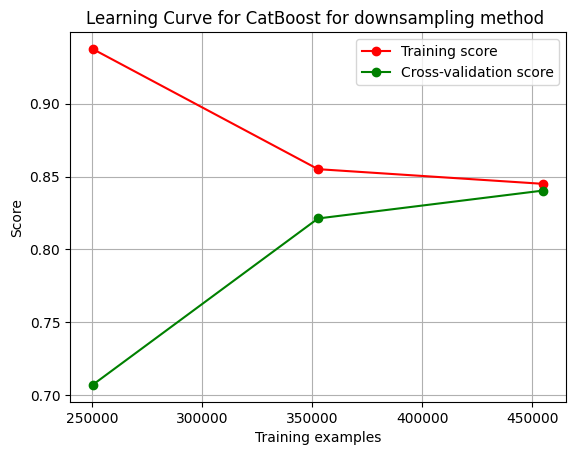

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 45513
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017959 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 45513, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped trainin

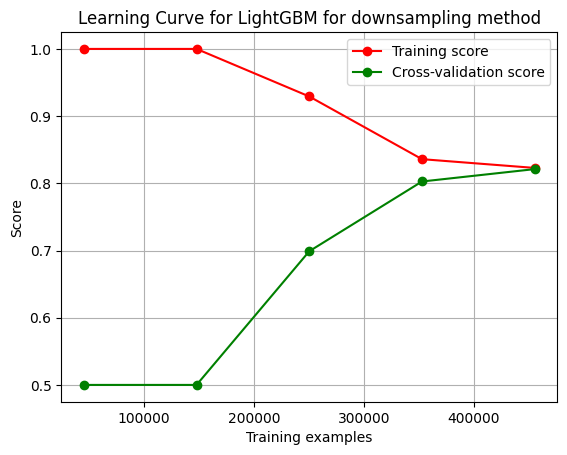

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()

    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

plot_learning_curve(LogisticRegression(**{'C': 0.1, 'solver': 'newton-cg'}), "Learning Curve for Logistic Regression for downsampling method", X_downsampled, y_downsampled, cv=5)
plt.show()


plot_learning_curve(CatBoostClassifier(**{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 7, 'learning_rate': 0.1}), "Learning Curve for CatBoost for downsampling method ", X_downsampled, y_downsampled, cv=5)
plt.show()
plot_learning_curve(LGBMClassifier(**{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators':   100}), "Learning Curve for LightGBM for downsampling method", X_downsampled, y_downsampled, cv=5)
plt.show()


#**Graph Analysis:**

**Learning Curve for Logistic Regression for downsampling method:**

**Training curve (red)**:

Starts at around 0.935, indicating good learning from the training data with some overfitting.

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at approximately 0.80.

**Cross-validation curve (green):**

The start is at a level of about 0.65, which indicates a low generalization ability of the model with a small amount of data.
As the number of training examples increases, the accuracy on cross-validation data increases significantly.
The curve stabilizes around the 0.80 level, indicating that the generalization ability of the model improves with more data.




**Learning Curve for CatBoost for downsampling method**

**Training curve (red):**

Starts at around 0.92, indicating good learning from the training data with some overfitting.

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at approximately 0.85.

**Cross-validation curve (green):**

The start is at a level of about 0.7, which indicates a low generalization ability of the model with a small amount of data.

As the number of training examples increases, the accuracy on cross-validation data increases significantly.

The curve stabilizes around the 0.85 level, indicating that the generalization ability of the model improves with more data.

**Learning Curve for LightGBM for downsampling method:**

**Training curve (red)**:

Starts at level 1, indicating perfect learning from the training data (overfitting).

As the number of training examples increases, the accuracy on the training data decreases.

The curve stabilizes at about 0.82, indicating that the model improves with more data.

**Cross-validation curve (green)**:

Starts at level 0.5, which indicates poor generalization ability of the model with a small amount of data.
As the number of training examples increases, the accuracy on cross-validation data increases significantly.

As the number of training examples increases, the accuracy on cross-validation data increases significantly.

The curve stabilizes around the level of 0.82, which indicates a good generalization ability of the model as the data increases.

#And now about Fully Connected Neural Network (FCNN)

#Number of layers and neurons in each package:

###1. The input layer will consist of a number of neurons equal to the number of features (in this case 21 (21 parametrs)).
###2. For hidden layers, I will choose 3 layers with gradually decreasing number of neurons:
### 1. 128 neurons(I chose the number of neurons large enough so that the network could learn complex dependencies between features.) with ReLU activation function.
###2. 64 neurons(It serves to further extract the feature hierarchy, as well as to reduce the dimensionality of the data before the final layers. This is the reason why there are already fewer neurons in it than in the previous layer) with ReLU activation function.
###3. 32 neurons(I reduce the number of neurons as I move through the network and this greatly helps the network focus on higher-level features) with ReLU activation function. This allows models to learn complex patterns at a high level of abstraction in early layers and refine them in simpler layers.

###I chose ReLU as the activation function for the hidden layers. The advantage of ReLU is that it promotes sparse activations, which speeds up training and improves the model's generalization ability. ReLU also helps avoid the problem of decaying gradients that is common with saturated activation functions.


###3.The output layer will consist of a single neuron with sigmoidal reduced efficiency for binary class prediction.
###For the output layer, I chose a sigmoid activation function, which transforms the neuron's output into an interval between 0 and 1, interpreted as guards to the positive class. Therefore, it is perfect for our task, the binary classification problem.

###Adam was selected as the optimizer with the learning_rate=0.001 parameter.


###Epochs and batch size are selected as standard: 50 epochs and batch size 32.

##**I will train FCNN on a dataset with the upsampling method**

In [ ]:
!pip install tensorflow


from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Масштабируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_upsampled)
X_test = scaler.transform(X_test)

# Построим модель
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    #т.к. у нас бин классификация
    Dense(1, activation='sigmoid')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_upsampled, y_upsampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Оценим модель
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Epoch 1/50
17779/17779 [==============================] - 54s 3ms/step - loss: 0.4315 - accuracy: 0.7981 - val_loss: 0.2725 - val_accuracy: 0.8977
Epoch 2/50
17779/17779 [==============================] - 59s 3ms/step - loss: 0.4200 - accuracy: 0.8031 - val_loss: 0.3347 - val_accuracy: 0.9137
Epoch 3/50
17779/17779 [==============================] - 47s 3ms/step - loss: 0.4168 - accuracy: 0.8048 - val_loss: 0.8125 - val_accuracy: 0.9023
Epoch 4/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4140 - accuracy: 0.8065 - val_loss: 0.8480 - val_accuracy: 0.9193
Epoch 5/50
17779/17779 [==============================] - 48s 3ms/step - loss: 0.4120 - accuracy: 0.8077 - val_loss: 1.2027 - val_accuracy: 0.9220
Epoch 6/50
17779/17779 [==============================] - 52s 3ms/step - loss: 0.4097 - accuracy: 0.8089 - val_loss: 2.1891 - val_accuracy: 0.9302
Epoch 7/50
17779/17779 [==============================] - 78s 4ms/step - loss: 0.4072 - accuracy: 0.8105 - val_loss: 2

'\nНесколько моделей я запускала на нескольких блокнотах\nРезультат:\n\n\n\n\n\n\nRequirement already satisfied: tensorflow in /usr/local/lib/python3.10/dist-packages (2.15.0)\nRequirement already satisfied: absl-py>=1.0.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.4.0)\nRequirement already satisfied: astunparse>=1.6.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.6.3)\nRequirement already satisfied: flatbuffers>=23.5.26 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (24.3.25)\nRequirement already satisfied: gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.6.0)\nRequirement already satisfied: google-pasta>=0.1.1 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.2.0)\nRequirement already satisfied: h5py>=2.9.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (3.9.0)\nRequirement already satisfied: libclang>=13.0.0 in /usr/local/lib/python3.10/dist-packages (f

##**I will train FCNN on a dataset with the downsampling method**

In [ ]:
!pip install tensorflow


from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam



scaler = StandardScaler()
X_train = scaler.fit_transform(X_downsampled)
X_test = scaler.transform(X_test)

# Построим модель
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    #т.к. у нас бин классификация
    Dense(1, activation='sigmoid')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_downsampled, y_downsampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Оценим модель
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


Epoch 1/50
17779/17779 [==============================] - 51s 3ms/step - loss: 0.4319 - accuracy: 0.7978 - val_loss: 0.2345 - val_accuracy: 0.8984
Epoch 2/50
17779/17779 [==============================] - 46s 3ms/step - loss: 0.4199 - accuracy: 0.8036 - val_loss: 0.2467 - val_accuracy: 0.9009
Epoch 3/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4168 - accuracy: 0.8052 - val_loss: 0.2899 - val_accuracy: 0.9005
Epoch 4/50
17779/17779 [==============================] - 53s 3ms/step - loss: 0.4144 - accuracy: 0.8069 - val_loss: 0.4029 - val_accuracy: 0.9032
Epoch 5/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4119 - accuracy: 0.8082 - val_loss: 0.5565 - val_accuracy: 0.9056
Epoch 6/50
17779/17779 [==============================] - 49s 3ms/step - loss: 0.4093 - accuracy: 0.8093 - val_loss: 0.6748 - val_accuracy: 0.9187
Epoch 7/50
17779/17779 [==============================] - 49s 3ms/step - loss: 0.4060 - accuracy: 0.8111 - val_loss: 0

##**We see that FCNN has a better result on downsapling, then I’ll analyze the different results on different activation functions**

In [ ]:

from tensorflow.keras.layers import LeakyReLU

scaler = StandardScaler()
X_train = scaler.fit_transform(X_downsampled)
X_test = scaler.transform(X_test)


model = Sequential([
    Dense(128, input_dim=X_train.shape[1]),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(32),
    LeakyReLU(alpha=0.01),
    Dense(1, activation='sigmoid')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_downsampled, y_downsampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Оценим модель
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Epoch 1/50
17779/17779 [==============================] - 54s 3ms/step - loss: 0.4319 - accuracy: 0.7982 - val_loss: 26.5705 - val_accuracy: 0.9430
Epoch 2/50
17779/17779 [==============================] - 47s 3ms/step - loss: 0.4198 - accuracy: 0.8037 - val_loss: 42.8943 - val_accuracy: 0.9431
Epoch 3/50
17779/17779 [==============================] - 51s 3ms/step - loss: 0.4162 - accuracy: 0.8059 - val_loss: 1623.9725 - val_accuracy: 0.0869
Epoch 4/50
17779/17779 [==============================] - 49s 3ms/step - loss: 0.4136 - accuracy: 0.8072 - val_loss: 6933.4775 - val_accuracy: 0.0746
Epoch 5/50
17779/17779 [==============================] - 48s 3ms/step - loss: 0.4101 - accuracy: 0.8088 - val_loss: 14809.2090 - val_accuracy: 0.0737
Epoch 6/50
17779/17779 [==============================] - 48s 3ms/step - loss: 0.4060 - accuracy: 0.8108 - val_loss: 20729.1621 - val_accuracy: 0.0741
Epoch 7/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4019 - accuracy: 0.81

#**As a result, we see that the accuracy has increased significantly**

In [ ]:

from tensorflow.keras.layers import LeakyReLU

scaler = StandardScaler()
X_train = scaler.fit_transform(X_downsampled)
X_test = scaler.transform(X_test)


model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='elu'),
    Dense(64, activation='elu'),
    Dense(32, activation='elu'),
    Dense(1, activation='sigmoid')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])


model.fit(X_downsampled, y_downsampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Оценим модель
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Epoch 1/50
17779/17779 [==============================] - 52s 3ms/step - loss: 0.4304 - accuracy: 0.7985 - val_loss: 5.9287 - val_accuracy: 0.6796
Epoch 2/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4193 - accuracy: 0.8035 - val_loss: 13.7032 - val_accuracy: 0.9434
Epoch 3/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4157 - accuracy: 0.8058 - val_loss: 37.3930 - val_accuracy: 0.9432
Epoch 4/50
17779/17779 [==============================] - 52s 3ms/step - loss: 0.4125 - accuracy: 0.8074 - val_loss: 63.4137 - val_accuracy: 0.9432
Epoch 5/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4084 - accuracy: 0.8097 - val_loss: 97.1882 - val_accuracy: 0.9432
Epoch 6/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.4033 - accuracy: 0.8124 - val_loss: 68.9320 - val_accuracy: 0.9434
Epoch 7/50
17779/17779 [==============================] - 50s 3ms/step - loss: 0.3980 - accuracy: 0.8151 - val_lo

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train = scaler.fit_transform(X_downsampled)
X_test = scaler.transform(X_test)

model = Sequential([
    Dense(128, input_dim=X_train.shape[1]),
    #для нормализации входных данных для ускорения обучения и стабильности модели
    BatchNormalization(),
    #чтобы избежать проблемы "умирающих" нейронов, характерной для ReLU
    LeakyReLU(alpha=0.01),
    #Dropout слой с коэффициентом 0.3 для предотвращения переобучения, чтобы улучшить обобщающую способность
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.3),

    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_downsampled, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


Epoch 1/50
17779/17779 [==============================] - 93s 5ms/step - loss: 0.4395 - accuracy: 0.7981 - val_loss: 0.4043 - val_accuracy: 0.8283
Epoch 2/50
17779/17779 [==============================] - 75s 4ms/step - loss: 0.4259 - accuracy: 0.8056 - val_loss: 0.4279 - val_accuracy: 0.8041
Epoch 3/50
17779/17779 [==============================] - 71s 4ms/step - loss: 0.4224 - accuracy: 0.8070 - val_loss: 0.3870 - val_accuracy: 0.8166
Epoch 4/50
17779/17779 [==============================] - 69s 4ms/step - loss: 0.4197 - accuracy: 0.8085 - val_loss: 0.3990 - val_accuracy: 0.8137
Epoch 5/50
17779/17779 [==============================] - 72s 4ms/step - loss: 0.4173 - accuracy: 0.8097 - val_loss: 0.3904 - val_accuracy: 0.8353
Epoch 6/50
17779/17779 [==============================] - 69s 4ms/step - loss: 0.4155 - accuracy: 0.8103 - val_loss: 0.3886 - val_accuracy: 0.8273
Epoch 7/50
17779/17779 [==============================] - 74s 4ms/step - loss: 0.4151 - accuracy: 0.8108 - val_loss: 0

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report


# Предсказание вероятностей для тестовых данных
y_pred_prob = model.predict(X_test)

# Преобразование вероятностей в классы с порогом 0.5
y_pred_class = (y_pred_prob > 0.5).astype(int)

# Вычисление ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC: {roc_auc}')

# Вычисление F1-score
f1 = f1_score(y_test, y_pred_class)
print(f'F1-score: {f1}')

# Полный отчет по метрикам
print(classification_report(y_test, y_pred_class))

#**As a result we have**:
#1. Using the upsampling method the following results were obtained:
  1. CatBoostClassifier: CatBoost Accuracy on test data: **0.8411852087643907**
  2. DummyClissifer: Dummy Accuracy on test data: **0.9432330627619502**
  3. Logistic Regression: Accuracy on test data: **0.8352299856756327**
  4. LightGBM: LightGBM Accuracy on test data: **0.843068597803597**
  5. FCNN with structure: 1) Dense(128, input_dim=X_train.shape[1], activation='relu'), 2) Dense(64, activation='relu'), 3) Dense(32, activation='relu'),4) Dense(1, activation='sigmoid'):
    Test Accuracy: **0.9244920015335083**

#2. Using the downsampling method the following results were obtained:
  1. CatBoostClassifier: CatBoost Accuracy on test data: **0.8411852087643907**
  2. DummyClissifer: Accuracy on test data: **0.8352299856756327**
  3. Logistic Regression: Accuracy on test data: **0.8352299856756327**
  4. LightGBM: LightGBM Accuracy on test data: **0.947729322510478**
  5. FCNN:
      1. with structure: 1) Dense(128, input_dim=X_train.shape[1], activation='relu'),2) Dense(64, activation='relu'), 3) Dense(32, activation='relu'), 4) Dense(1, activation='sigmoid')
      Test Accuracy: **0.9294790029525757**

      2. with structure: 1) Dense(128, input_dim=X_train.shape[1]), LeakyReLU(alpha=0.01), 2) Dense(64), LeakyReLU(alpha=0.01), 3) Dense(32), LeakyReLu
      (alpha=0.01), 4) Dense(1, activation='sigmoid')
      Test Accuracy: **0.943233072757721**

      3. with structure: 1) Dense(128, input_dim=X_train.shape[1], activation='elu'), 2) Dense(64, activation='elu'), 3) Dense(32, activation='elu'), 4) Dense(1,activation='sigmoid')
      Test Accuracy: **0.943233072757721**

      4. with structure: 1) Dense(128, input_dim=X_train.shape[1]), BatchNormalization(), LeakyReLU(alpha=0.01), Dropout(0.3), 2) Dense(64),BatchNormalization(), LeakyReLU(alpha=0.01), Dropout(0.3), 3) Dense(32),BatchNormalization(), LeakyReLU(alpha=0.01), Dropout(0.3), 4) Dense(1, activation='sigmoid')
      Test Accuracy: **0.8307602405548096**

#3. Using machine learning models with a custom parameter class_weights, I configured class_weight='balanced':
  **1. Using the downsampling method the following results were obtained:**

  **1. LogisticRegression:**

                  precision    recall  f1-score   support

           0       0.98      0.86      0.92     71116

           1       0.24      0.71      0.35      4280

      accuracy                         0.85     75396

      macro avg       0.61      0.79      0.64     75396
    
      weighted avg    0.94      0.85      0.89     75396


      
  **2.RandomForestClassifier:**

                precision    recall  f1-score   support

    0              0.94      1.00      0.97     71116
    1              0.00      0.00      0.00      4280

    accuracy                           0.94     75396

    macro avg      0.47      0.50      0.49     75396

    weighted avg   0.89      0.94      0.92     75396

And we see that:

Value for class 1:

Precision 0.00: This means that the model did not predict any positive cases (class 1) correctly.

All predictions for class 1 were incorrect.

Recall 0.00: This indicates that the model was unable to find any true positive cases among all class 1 examples. In other words, the model did not recognize any class 1 cases.

F1-score 0.00: F1-score is 0 because both precision and recall are 0.

This means that the **model completely fails to predict** the positive class (class 1).
  2. **Using the upsampling method the following results were obtained:**

**1. LogisticRegression:**

                  precision    recall  f1-score   support

    0               0.98      0.86      0.92     71116
    1               0.24      0.71      0.35      4280

    accuracy                            0.85     75396
    macro avg       0.61      0.79      0.64     75396
    weighted avg    0.94      0.85      0.89     75396


**2.RandomForestClassifier:**

                 precision    recall  f1-score   support

    0               0.94      1.00      0.97     71116
    1               0.00      0.00      0.00      4280

    accuracy                            0.94     75396
    macro avg       0.47      0.50      0.49     75396
    weighted avg    0.89      0.94      0.92     75396

And we see that:

Value for class 1:

Precision 0.00: This means that the model did not predict any positive cases (class 1) correctly.

All predictions for class 1 were incorrect.

Recall 0.00: This indicates that the model was unable to find any true positive cases among all class 1 examples. In other words, the model did not recognize any class 1 cases.

F1-score 0.00: F1-score is 0 because both precision and recall are 0.

#Conclusions:
#Among the different models and methods analyzed,FCNN (ELU)  Downsampling  and  FCNN (LeakyReLU)  Downsampling  achieved the highest accuracy on the test data
